# GAM Analysis using enhanced_summed_47photic.parquet data


1. Exploratory Data Analysis (EDA)
2. Initial flexible GAM to assess functional forms
3. Model simplification based on EDF
4. Model comparison and selection
5. Final model diagnostics and validation

## 1. Load and Prepare Data

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LinearGAM, s, l, f, GAM
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats


In [126]:
# Load data
df = pd.read_parquet("../data/Parquet/enhanced_summed_47photic.parquet")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (1971, 41)

Columns: ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'K_PAR', 'K_PAR_SLOPE']


In [127]:
# Identify PAR-related variables (capitalized)

# This dataset does not have ESTCHL_SUMMED OR PHAEO_SUMMED
variables = ['LINE', 'STA', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'Lat_Dec', 'Lon_Dec', 'K_PAR', 'K_PAR_SLOPE']
target = 'Secchi'

# Create clean dataset
df_clean = df[variables + [target]].dropna()

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Missing values removed: {df.shape[0] - df_clean.shape[0]}")
print(f"\nVariables for modeling:")
print(f"  Predictors: {variables}")
print(f"  Target: {target}")

Clean dataset shape: (1971, 11)
Missing values removed: 0

Variables for modeling:
  Predictors: ['LINE', 'STA', 'DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'Lat_Dec', 'Lon_Dec', 'K_PAR', 'K_PAR_SLOPE']
  Target: Secchi


In [128]:
# Basic statistics
print("Descriptive Statistics:")
print(df_clean.describe())

Descriptive Statistics:
              LINE          STA        DEPTH  ESTCHL_STACORR  XMISS_SUMMED  \
count  1971.000000  1971.000000  1971.000000     1971.000000   1971.000000   
mean     86.114307    64.759411    39.758498        1.297240   2711.761325   
std       6.100628    25.742855    20.182505        2.689614   2031.600068   
min      60.000000     3.000000     3.000000        0.000000  -6831.000000   
25%      83.300000    45.000000    24.000000        0.290000   1189.345000   
50%      86.700000    60.000000    37.000000        0.580000   2495.210000   
75%      90.000000    80.000000    52.000000        1.080000   3958.465000   
max      93.300000   120.000000   137.000000       50.027800  11486.175900   

       CHL_A_SUMMED      Lat_Dec      Lon_Dec        K_PAR  K_PAR_SLOPE  \
count   1971.000000  1971.000000  1971.000000  1971.000000  1971.000000   
mean       3.703496    32.929796  -120.750482     0.128475     0.151641   
std        5.859885     1.289528     1.966866   

## 2. Exploratory Data Analysis

Visualize relationships to understand which variables need non-linear terms

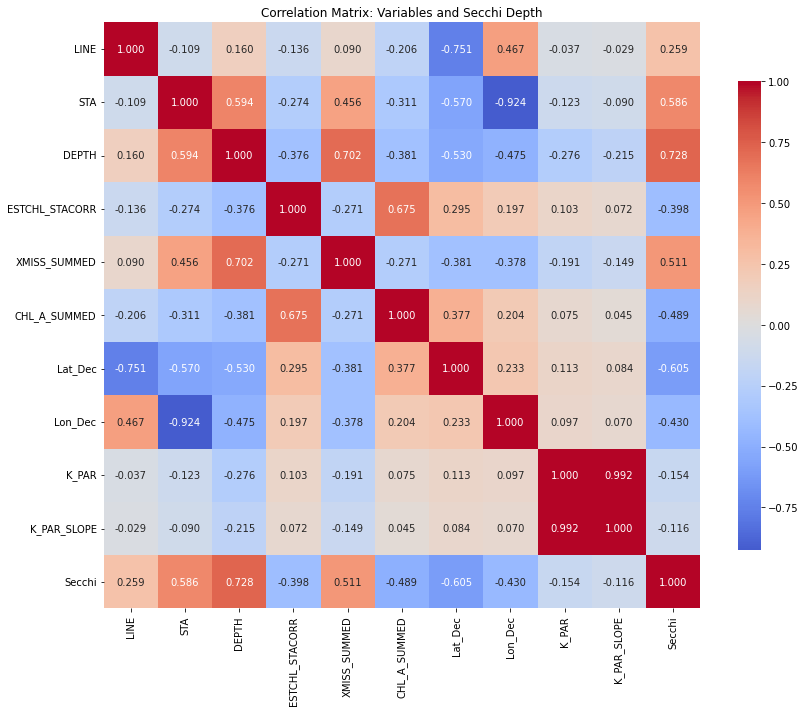


Correlations with Secchi depth:
Secchi            1.000000
DEPTH             0.728275
STA               0.585580
XMISS_SUMMED      0.511352
LINE              0.259437
K_PAR_SLOPE      -0.116042
K_PAR            -0.154399
ESTCHL_STACORR   -0.398280
Lon_Dec          -0.429824
CHL_A_SUMMED     -0.489360
Lat_Dec          -0.604798
Name: Secchi, dtype: float64


In [129]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix: Variables and Secchi Depth')
plt.tight_layout()
plt.show()

print("\nCorrelations with Secchi depth:")
print(df_clean.corr()[target].sort_values(ascending=False))

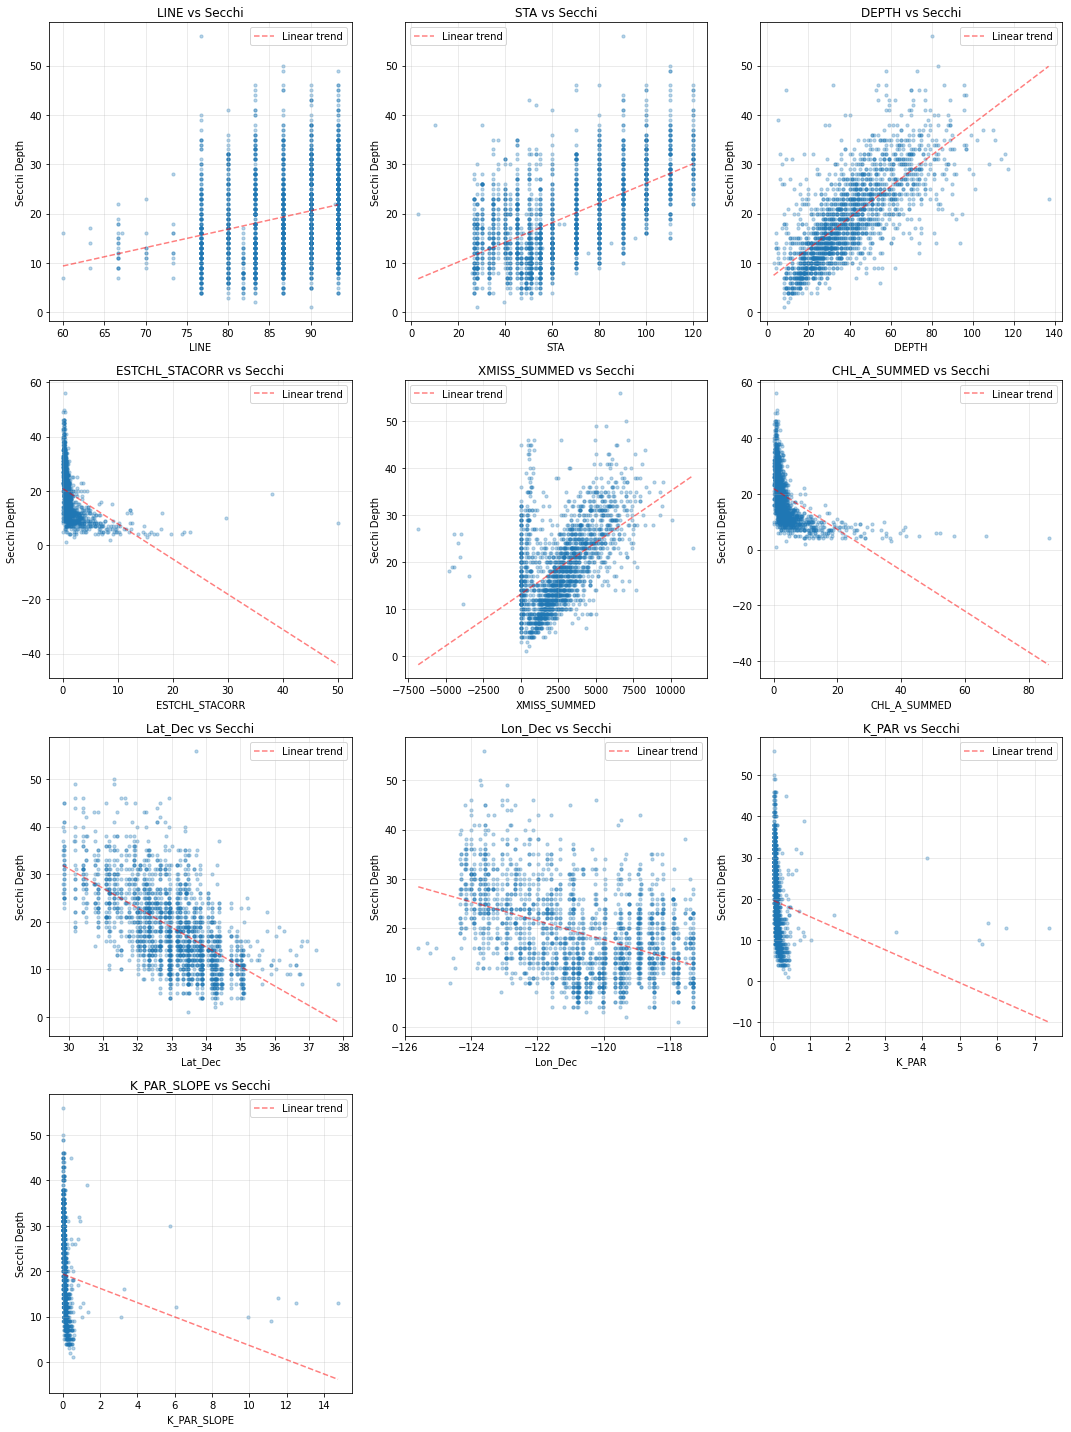

In [130]:
# Scatter plots for each predictor vs Secchi
n_vars = len(variables)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].scatter(df_clean[var], df_clean[target], alpha=0.3, s=10)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Secchi Depth')
    axes[i].set_title(f'{var} vs Secchi')
    
    # Add trend line
    z = np.polyfit(df_clean[var], df_clean[target], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_clean[var].min(), df_clean[var].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', alpha=0.5, label='Linear trend')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Remove extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Linear relationships -> Consider linear terms l()
Curved patterns -> Need smooth terms s()
No clear pattern -> Variable may not be useful

## 3. Prepare Train/Test Split

In [131]:
# Prepare X and y
X = df_clean[variables].values
y = df_clean[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 1576 samples
Test set: 395 samples


## 4. Fit Initial Flexible GAM

Start with all smooth terms to assess which variables need non-linear functions

In [132]:
# Fit GAM with all smooth terms
gam_flexible = LinearGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9)
).fit(X_train, y_train)

# Get predictions
y_pred_train = gam_flexible.predict(X_train)
y_pred_test = gam_flexible.predict(X_test)

# Performance metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("="*70)
print("FLEXIBLE GAM (ALL SMOOTH TERMS)")
print("="*70)
print(f"\nTraining Set:")
print(f"  R²: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"\nTest Set:")
print(f"  R²: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"\nModel Statistics:")
print(f"  AIC: {gam_flexible.statistics_['AIC']:.2f}")
print(f"  GCV: {gam_flexible.statistics_['GCV']:.4f}")

FLEXIBLE GAM (ALL SMOOTH TERMS)

Training Set:
  R²: 0.7421
  RMSE: 4.4351

Test Set:
  R²: 0.6715
  RMSE: 5.0486

Model Statistics:
  AIC: 12718.72
  GCV: 23.1649


In [133]:
print("\n" + "="*70)
print("EFFECTIVE DEGREES OF FREEDOM (EDF) ANALYSIS")
print("="*70)
print("(EDF ≈ 1 suggests linear relationship)\n")

# Get EDF per coefficient
edof_per_coef = gam_flexible.statistics_['edof_per_coef']

# Calculate EDF for each term by summing over its basis functions
edfs = []
current_idx = 0

for i, term in enumerate(gam_flexible.terms):
    if term.isintercept:
        current_idx += 1  # Skip intercept
        continue
    
    # Number of coefficients for this term
    n_coefs = term.n_coefs
    
    # Sum the EDFs for this term's coefficients
    term_edf = edof_per_coef[current_idx:current_idx + n_coefs].sum()
    edfs.append(term_edf)
    
    current_idx += n_coefs

edfs = np.array(edfs)

print(f"Total EDF (excluding intercept): {edfs.sum():.2f}")
print(f"Model total EDF: {gam_flexible.statistics_['edof']:.2f}")
print(f"\nIndividual term EDFs:\n")

for i, var in enumerate(variables):
    edf = edfs[i]
    if edf < 1.5:
        interpretation = "LINEAR"
        recommendation = "Use l()"
    elif edf < 3:
        interpretation = "MILDLY NON-LINEAR"
        recommendation = "Keep s()"
    else:
        interpretation = "STRONGLY NON-LINEAR"
        recommendation = "Keep s()"
    
    print(f"  {var:20s}: EDF = {edf:5.2f}  [{interpretation:20s}] → {recommendation}")

print("\nRecommendation:")
print("  EDF < 1.5  → Use linear term l()")
print("  EDF ≥ 1.5  → Keep smooth term s()")

if edfs.sum() > 30:
    print("\n⚠️  WARNING: Total EDF is very high (>30)!")
    print("    This suggests potential overfitting.")
    print("    Grid search for optimal smoothing is CRITICAL.")


EFFECTIVE DEGREES OF FREEDOM (EDF) ANALYSIS
(EDF ≈ 1 suggests linear relationship)

Total EDF (excluding intercept): 88.38
Model total EDF: 88.38

Individual term EDFs:

  LINE                : EDF = 11.25  [STRONGLY NON-LINEAR ] → Keep s()
  STA                 : EDF = 12.42  [STRONGLY NON-LINEAR ] → Keep s()
  DEPTH               : EDF = 13.81  [STRONGLY NON-LINEAR ] → Keep s()
  ESTCHL_STACORR      : EDF =  8.18  [STRONGLY NON-LINEAR ] → Keep s()
  XMISS_SUMMED        : EDF =  8.24  [STRONGLY NON-LINEAR ] → Keep s()
  CHL_A_SUMMED        : EDF =  6.86  [STRONGLY NON-LINEAR ] → Keep s()
  Lat_Dec             : EDF = 10.77  [STRONGLY NON-LINEAR ] → Keep s()
  Lon_Dec             : EDF = 10.10  [STRONGLY NON-LINEAR ] → Keep s()
  K_PAR               : EDF =  6.29  [STRONGLY NON-LINEAR ] → Keep s()
  K_PAR_SLOPE         : EDF =  0.47  [LINEAR              ] → Use l()

Recommendation:
  EDF < 1.5  → Use linear term l()
  EDF ≥ 1.5  → Keep smooth term s()

⚠️  WARNING: Total EDF is very 

## 6. Grid Search for Optimal Smoothing

**CRITICAL STEP:** Since EDF is high, we need to find optimal smoothing parameters to prevent overfitting

In [134]:
print("\n" + "="*70)
print("GRID SEARCH FOR OPTIMAL SMOOTHING PENALTY")
print("="*70)

# Search over lambda values to reduce overfitting
lams = np.logspace(-3, 5, 20)  # Range of lambda values

print("\nPerforming grid search for optimal lambda...")
print("This may take a minute...\n")

gam_gridsearch = LinearGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + s(8) + s(9)
).gridsearch(X_train, y_train, lam=lams)

print(f"Optimal lambda values found:")
for i, var in enumerate(variables):
    print(f"  {var:20s}: λ = {gam_gridsearch.lam[i][0]:.4f}")

print(f"\nOptimized model EDF: {gam_gridsearch.statistics_['edof']:.2f}")
print(f"Original model EDF: {edfs.sum():.2f}")
print(f"EDF reduction: {edfs.sum() - gam_gridsearch.statistics_['edof']:.2f}")

# Update the flexible model with optimized version
gam_flexible = gam_gridsearch

# Recalculate EDFs with optimized lambda
edof_per_coef = gam_flexible.statistics_['edof_per_coef']
edfs_optimized = []
current_idx = 0

for i, term in enumerate(gam_flexible.terms):
    if term.isintercept:
        current_idx += 1
        continue
    
    n_coefs = term.n_coefs
    term_edf = edof_per_coef[current_idx:current_idx + n_coefs].sum()
    edfs_optimized.append(term_edf)
    current_idx += n_coefs

edfs = np.array(edfs_optimized)

print(f"\nOptimized Individual term EDFs:\n")
for i, var in enumerate(variables):
    edf = edfs[i]
    if edf < 1.5:
        interpretation = "LINEAR"
        recommendation = "Use l()"
    elif edf < 3:
        interpretation = "MILDLY NON-LINEAR"
        recommendation = "Keep s()"
    else:
        interpretation = "STRONGLY NON-LINEAR"
        recommendation = "Keep s()"
    
    print(f"  {var:20s}: EDF = {edf:5.2f}  [{interpretation:20s}] → {recommendation}")

# Get performance after optimization
y_pred_train_opt = gam_flexible.predict(X_train)
y_pred_test_opt = gam_flexible.predict(X_test)

print(f"\nOptimized Model Performance:")
print(f"  Training R²: {r2_score(y_train, y_pred_train_opt):.4f}")
print(f"  Test R²: {r2_score(y_test, y_pred_test_opt):.4f}")
print(f"  Training RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_opt)):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_opt)):.4f}")

  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--



GRID SEARCH FOR OPTIMAL SMOOTHING PENALTY

Performing grid search for optimal lambda...
This may take a minute...



  5% (1 of 20) |#                        | Elapsed Time: 0:00:00 ETA:   0:00:14
 10% (2 of 20) |##                       | Elapsed Time: 0:00:01 ETA:   0:00:11
 15% (3 of 20) |###                      | Elapsed Time: 0:00:01 ETA:   0:00:10
 20% (4 of 20) |#####                    | Elapsed Time: 0:00:02 ETA:   0:00:09
 25% (5 of 20) |######                   | Elapsed Time: 0:00:02 ETA:   0:00:08
 30% (6 of 20) |#######                  | Elapsed Time: 0:00:03 ETA:   0:00:07
 35% (7 of 20) |########                 | Elapsed Time: 0:00:03 ETA:   0:00:07
 40% (8 of 20) |##########               | Elapsed Time: 0:00:04 ETA:   0:00:06
 45% (9 of 20) |###########              | Elapsed Time: 0:00:04 ETA:   0:00:06
 50% (10 of 20) |############            | Elapsed Time: 0:00:05 ETA:   0:00:05
 55% (11 of 20) |#############           | Elapsed Time: 0:00:05 ETA:   0:00:04
 60% (12 of 20) |##############          | Elapsed Time: 0:00:06 ETA:   0:00:04
 65% (13 of 20) |###############        

Optimal lambda values found:
  LINE                : λ = 2.3357
  STA                 : λ = 2.3357
  DEPTH               : λ = 2.3357
  ESTCHL_STACORR      : λ = 2.3357
  XMISS_SUMMED        : λ = 2.3357
  CHL_A_SUMMED        : λ = 2.3357
  Lat_Dec             : λ = 2.3357
  Lon_Dec             : λ = 2.3357
  K_PAR               : λ = 2.3357
  K_PAR_SLOPE         : λ = 2.3357

Optimized model EDF: 72.62
Original model EDF: 88.38
EDF reduction: 15.76

Optimized Individual term EDFs:

  LINE                : EDF = 10.10  [STRONGLY NON-LINEAR ] → Keep s()
  STA                 : EDF = 11.02  [STRONGLY NON-LINEAR ] → Keep s()
  DEPTH               : EDF = 11.51  [STRONGLY NON-LINEAR ] → Keep s()
  ESTCHL_STACORR      : EDF =  6.76  [STRONGLY NON-LINEAR ] → Keep s()
  XMISS_SUMMED        : EDF =  6.57  [STRONGLY NON-LINEAR ] → Keep s()
  CHL_A_SUMMED        : EDF =  5.24  [STRONGLY NON-LINEAR ] → Keep s()
  Lat_Dec             : EDF =  8.51  [STRONGLY NON-LINEAR ] → Keep s()
  Lon_Dec      

## 7. Visualize Partial Dependence Plots

Show the learned smooth functions for each variable (after optimization)

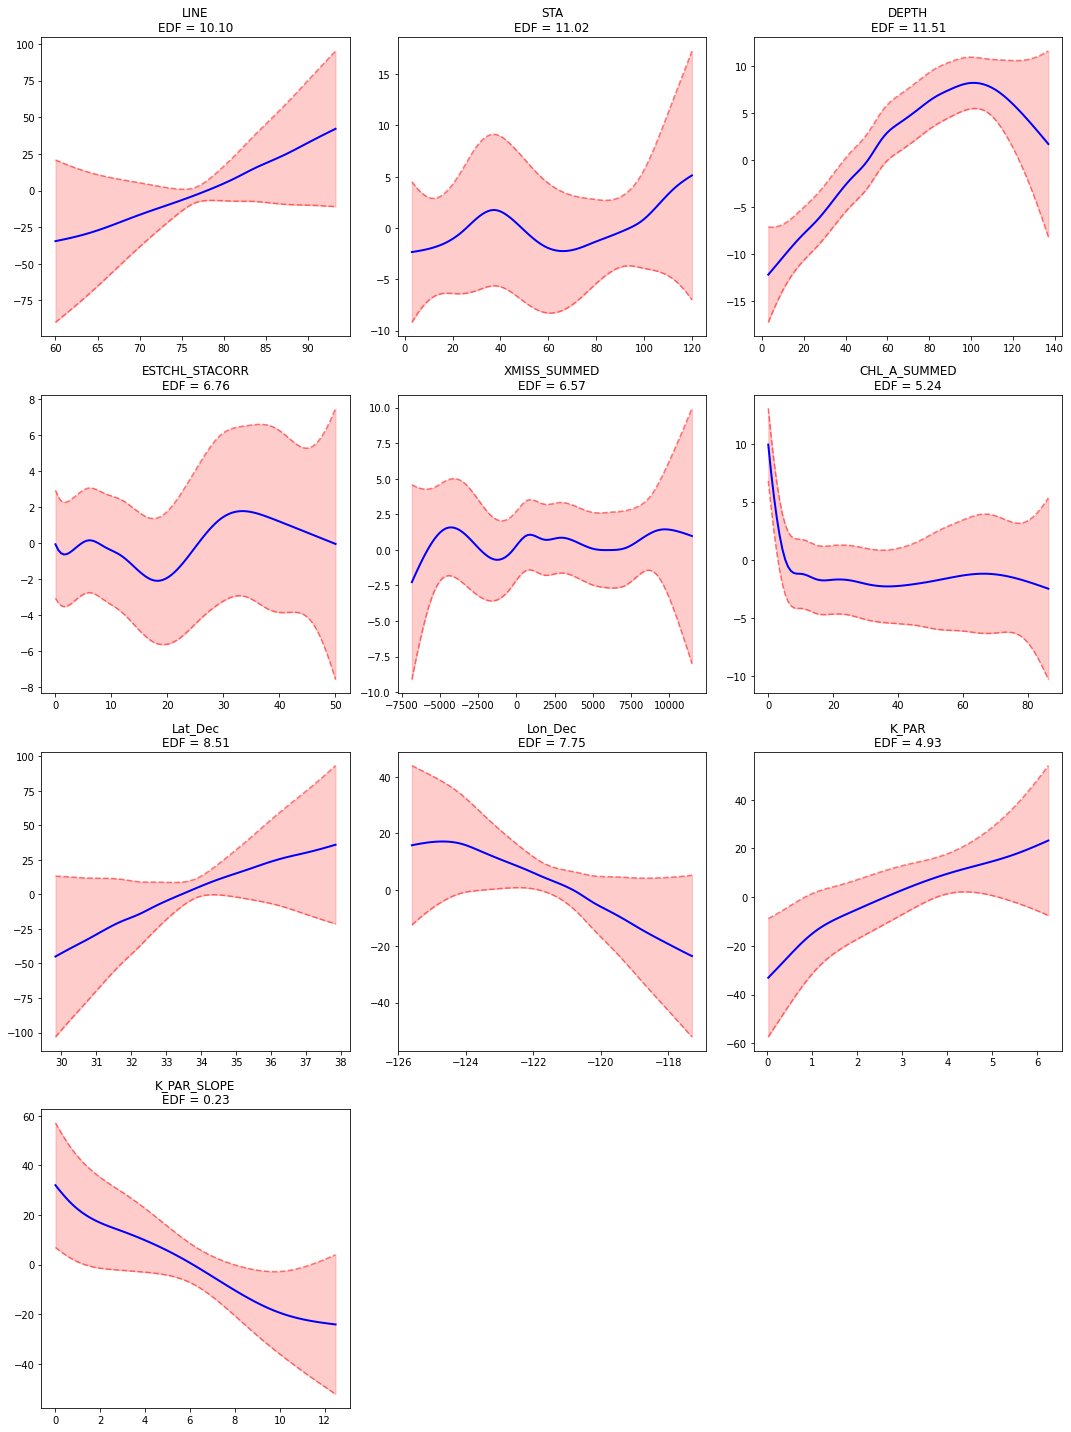

In [135]:
# Plot partial dependence for each feature
n_vars = len(variables)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    XX = gam_flexible.generate_X_grid(term=i)

    pdep, conf = gam_flexible.partial_dependence(
        term=i,
        X=XX,
        width=0.95
    )

    lower = conf[:, 0]
    upper = conf[:, 1]

    axes[i].plot(XX[:, i], pdep, 'b-', linewidth=2, label='Partial effect')
    axes[i].plot(XX[:, i], lower, 'r--', alpha=0.5)
    axes[i].plot(XX[:, i], upper, 'r--', alpha=0.5)
    axes[i].fill_between(XX[:, i], lower, upper, alpha=0.2, color='red')
    axes[i].set_title(f"{var}\nEDF = {edfs[i]:.2f}", fontsize=12)

# Remove extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Interpretation:
Straight lines suggest linear relationships
Curves show non-linear effects
Wide confidence bands suggest high uncertainty

## 8. Build Alternative Models Based on EDF

In [136]:
print("\n" + "="*70)
print("BUILDING ALTERNATIVE MODELS")
print("="*70)

# Model 1: Optimized smooth (baseline)
model_specs = {
    'Optimized Smooth': s(0, lam=gam_flexible.lam[0]) + s(1, lam=gam_flexible.lam[1]) + 
                        s(2, lam=gam_flexible.lam[2]) + s(3, lam=gam_flexible.lam[3]) + 
                        s(4, lam=gam_flexible.lam[4]) + s(5, lam=gam_flexible.lam[5]) + 
                        s(6, lam=gam_flexible.lam[6]) + s(7, lam=gam_flexible.lam[7]) +
                        s(8, lam=gam_flexible.lam[8]) + s(9, lam=gam_flexible.lam[9])
}

# Model 2: EDF Simplified (convert EDF < 1.5 to linear)
terms_simplified = []
for i, edf in enumerate(edfs):
    if edf < 1.5:
        terms_simplified.append(l(i))
    else:
        terms_simplified.append(s(i, lam=gam_flexible.lam[i]))
model_specs['EDF Simplified'] = sum(terms_simplified[1:], terms_simplified[0])

# Model 3: Conservative (convert EDF < 3 to linear)
terms_conservative = []
for i, edf in enumerate(edfs):
    if edf < 3.0:
        terms_conservative.append(l(i))
    else:
        terms_conservative.append(s(i, lam=gam_flexible.lam[i]))
model_specs['Conservative'] = sum(terms_conservative[1:], terms_conservative[0])

# Model 4: All linear (for comparison)
model_specs['All Linear'] = l(0) + l(1) + l(2) + l(3) + l(4) + l(5) + l(6) + l(7) + l(8) + l(9)

print(f"\nCreated {len(model_specs)} model specifications:")
for name in model_specs.keys():
    print(f"  - {name}")


BUILDING ALTERNATIVE MODELS

Created 4 model specifications:
  - Optimized Smooth
  - EDF Simplified
  - Conservative
  - All Linear


Created 5 models:
Optimized Smooth: Fully flexible baseline (most complex)
EDF Simplified: Remove splines where EDF ≈ linear
Conservative: Only allow strong nonlinearities
All Linear: Pure linear regression baseline
Top 5 Variables: Dimensionality reduction

## 9. Compare Models with Cross-Validation

In [137]:
def cross_validate_gam(X, y, formula, n_folds=5):
    """Cross-validate a GAM model"""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    rmse_scores = []
    r2_scores = []
    mae_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        try:
            # Fit model
            gam = GAM(formula).fit(X_train_fold, y_train_fold)
            
            # Predict
            y_pred = gam.predict(X_val_fold)
            
            # Calculate metrics
            rmse_scores.append(np.sqrt(mean_squared_error(y_val_fold, y_pred)))
            r2_scores.append(r2_score(y_val_fold, y_pred))
            mae_scores.append(mean_absolute_error(y_val_fold, y_pred))
        except Exception as e:
            print(f"  Warning: Fold failed with error: {e}")
            continue
    
    if len(rmse_scores) == 0:
        return {
            'RMSE': (np.nan, np.nan),
            'R2': (np.nan, np.nan),
            'MAE': (np.nan, np.nan)
        }
    
    return {
        'RMSE': (np.mean(rmse_scores), np.std(rmse_scores)),
        'R2': (np.mean(r2_scores), np.std(r2_scores)),
        'MAE': (np.mean(mae_scores), np.std(mae_scores))
    }

# Compare all models
print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS (5-FOLD)")
print("="*70)
print(f"\n{'Model':<25} {'RMSE':<20} {'R²':<20} {'MAE':<20}")
print("="*85)

cv_results = {}
for name, formula in model_specs.items():
    print(f"Validating {name}...", end=" ")
    results = cross_validate_gam(X_train, y_train, formula)
    cv_results[name] = results
    
    rmse_mean, rmse_std = results['RMSE']
    r2_mean, r2_std = results['R2']
    mae_mean, mae_std = results['MAE']
    
    if not np.isnan(rmse_mean):
        print(f"\n{name:<25} {rmse_mean:6.3f} ± {rmse_std:5.3f}    "
              f"{r2_mean:6.3f} ± {r2_std:5.3f}    "
              f"{mae_mean:6.3f} ± {mae_std:5.3f}")
    else:
        print(f"\n{name:<25} FAILED")

print("\n" + "="*70)
print("BEST MODEL SELECTION CRITERIA:")
print("="*70)
print("  - Highest R² (with reasonable RMSE)")
print("  - Lower standard deviation suggests more stable model")
print("  - Prefer simpler models if performance is similar")

# Find best model based on R2
valid_results = {k: v for k, v in cv_results.items() if not np.isnan(v['R2'][0])}
if len(valid_results) > 0:
    best_model_name = max(valid_results.items(), key=lambda x: x[1]['R2'][0])[0]
    print(f"\nBest model by R²: {best_model_name}")
    print(f"  R² = {cv_results[best_model_name]['R2'][0]:.4f} ± {cv_results[best_model_name]['R2'][1]:.4f}")
    print(f"  RMSE = {cv_results[best_model_name]['RMSE'][0]:.4f} ± {cv_results[best_model_name]['RMSE'][1]:.4f}")
else:
    best_model_name = 'Optimized Smooth'
    print(f"\nDefaulting to: {best_model_name}")


CROSS-VALIDATION RESULTS (5-FOLD)

Model                     RMSE                 R²                   MAE                 
Validating Optimized Smooth... 
Optimized Smooth           5.099 ± 0.981     0.654 ± 0.112     3.610 ± 0.246
Validating EDF Simplified... 
EDF Simplified             5.096 ± 0.991     0.654 ± 0.114     3.607 ± 0.243
Validating Conservative... 
Conservative               5.096 ± 0.991     0.654 ± 0.114     3.607 ± 0.243
Validating All Linear... 
All Linear                 5.237 ± 0.218     0.639 ± 0.020     3.984 ± 0.092

BEST MODEL SELECTION CRITERIA:
  - Highest R² (with reasonable RMSE)
  - Lower standard deviation suggests more stable model
  - Prefer simpler models if performance is similar

Best model by R²: EDF Simplified
  R² = 0.6543 ± 0.1138
  RMSE = 5.0961 ± 0.9912


## 10. Select and Refit Final Model

Choose the best model and fit on full training data

In [138]:
best_model_name = 'EDF Simplified'  # Best model based on CV results (update if needed)
best_formula = model_specs[best_model_name]

print(f"Selected model: {best_model_name}\n")

# Fit final model on full training data
final_gam = GAM(best_formula).fit(X_train, y_train)

# Get predictions
y_pred_train_final = final_gam.predict(X_train)
y_pred_test_final = final_gam.predict(X_test)

# Performance on train and test
print("Final Model Performance:")
print(f"\nTraining Set:")
print(f"  R²: {r2_score(y_train, y_pred_train_final):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_final)):.4f}")
print(f"  MAE: {mean_absolute_error(y_train, y_pred_train_final):.4f}")

print(f"\nTest Set:")
print(f"  R²: {r2_score(y_test, y_pred_test_final):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_final)):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_test_final):.4f}")

print(f"\nModel Statistics:")
print(f"  AIC: {final_gam.statistics_['AIC']:.2f}")
print(f"  GCV: {final_gam.statistics_['GCV']:.4f}")

print("\nFull Model Summary:")
print(final_gam.summary())

Selected model: EDF Simplified

Final Model Performance:

Training Set:
  R²: 0.7346
  RMSE: 4.4986
  MAE: 3.3742

Test Set:
  R²: 0.6720
  RMSE: 5.0446
  MAE: 3.8465

Model Statistics:
  AIC: 12741.37
  GCV: 23.1065

Full Model Summary:
GAM                                                                                                       
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     72.2046
Link Function:                     IdentityLink Log Likelihood:                                 -6297.4793
Number of Samples:                         1576 AIC:                                            12741.3678
                                                AICc:                                            12748.602
                                                GCV:                                               23.1065
             

/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_1791/1739625152.py:30: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(final_gam.summary())


## 11. Model Diagnostics

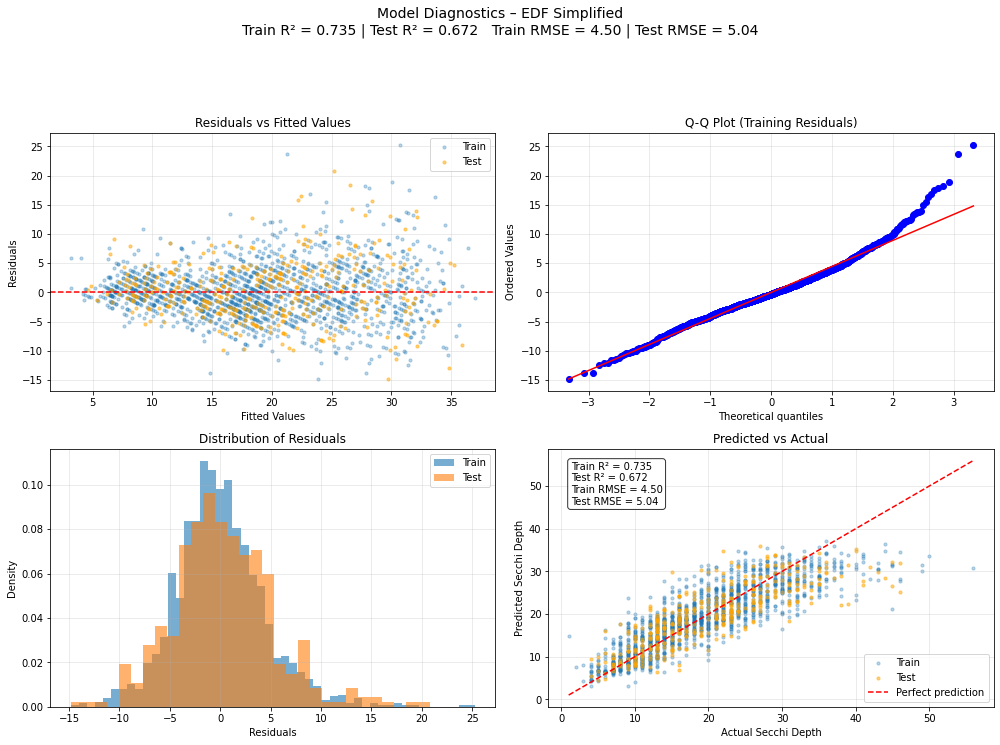


Diagnostic Interpretation:
  1. Residuals vs Fitted: Should show random scatter around 0 (no patterns)
  2. Q-Q Plot: Points should follow the diagonal line (normal residuals)
  3. Histogram: Should be approximately normal (bell-shaped)
  4. Predicted vs Actual: Points should cluster around the diagonal line


In [139]:
train_r2 = r2_score(y_train, y_pred_train_final)
test_r2 = r2_score(y_test, y_pred_test_final)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_final))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_final))

# Calculate residuals
residuals_train = y_train - y_pred_train_final
residuals_test = y_test - y_pred_test_final

# Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred_train_final, residuals_train, alpha=0.3, s=10, label='Train')
axes[0, 0].scatter(y_pred_test_final, residuals_test, alpha=0.5, s=10, label='Test', color='orange')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot (normality of residuals)
stats.probplot(residuals_train, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Training Residuals)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histogram of residuals
axes[1, 0].hist(residuals_train, bins=50, alpha=0.6, label='Train', density=True)
axes[1, 0].hist(residuals_test, bins=30, alpha=0.6, label='Test', density=True)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Predicted vs Actual
axes[1, 1].scatter(y_train, y_pred_train_final, alpha=0.3, s=10, label='Train')
axes[1, 1].scatter(y_test, y_pred_test_final, alpha=0.5, s=10, label='Test', color='orange')
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[1, 1].set_xlabel('Actual Secchi Depth')
axes[1, 1].set_ylabel('Predicted Secchi Depth')
axes[1, 1].set_title('Predicted vs Actual')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].text(
    0.05, 0.95,
    f"Train R² = {train_r2:.3f}\n"
    f"Test R² = {test_r2:.3f}\n"
    f"Train RMSE = {train_rmse:.2f}\n"
    f"Test RMSE = {test_rmse:.2f}",
    transform=axes[1, 1].transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Add overall model title + metrics
fig.suptitle(
    f"Model Diagnostics – {best_model_name}\n"
    f"Train R² = {train_r2:.3f} | Test R² = {test_r2:.3f}   "
    f"Train RMSE = {train_rmse:.2f} | Test RMSE = {test_rmse:.2f}",
    fontsize=14,
    y=1.03
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


print("\nDiagnostic Interpretation:")
print("  1. Residuals vs Fitted: Should show random scatter around 0 (no patterns)")
print("  2. Q-Q Plot: Points should follow the diagonal line (normal residuals)")
print("  3. Histogram: Should be approximately normal (bell-shaped)")
print("  4. Predicted vs Actual: Points should cluster around the diagonal line")

## 12. Feature Importance Analysis


FEATURE IMPORTANCE ANALYSIS

Ranked by Range of Partial Effect:
      Variable  Importance       EDF  Correlation  Normalized Importance
       Lat_Dec   80.045323  8.487875    -0.604798               0.240034
          LINE   75.890009 10.118188     0.259437               0.227574
   K_PAR_SLOPE   45.894574  0.038963    -0.116042               0.137626
         K_PAR   40.494435  3.847142    -0.154399               0.121432
       Lon_Dec   40.269325  7.768554    -0.429824               0.120757
         DEPTH   22.295088 10.920940     0.728275               0.066857
  CHL_A_SUMMED   12.633108  4.961950    -0.489360               0.037883
           STA    7.487816 11.017037     0.585580               0.022454
ESTCHL_STACORR    4.593293  8.507084    -0.398280               0.013774
  XMISS_SUMMED    3.871345  6.536855     0.511352               0.011609


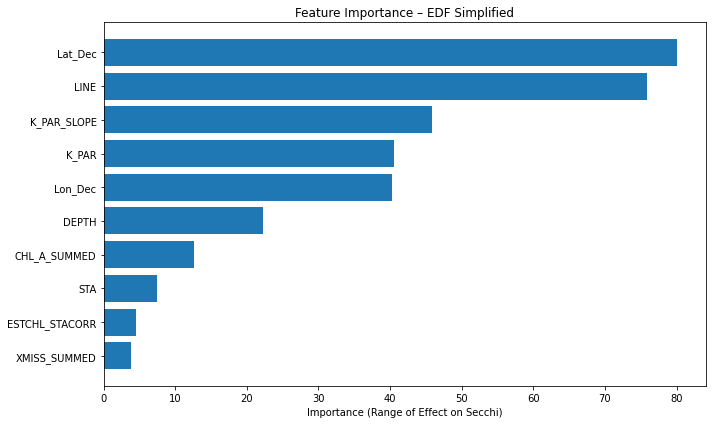

In [140]:
# Feature Importance (FINAL GAM)

importance_scores = []
model_vars = []

# Loop through actual GAM terms (skip intercept)
for i, term in enumerate(final_gam.terms):
    
    if term.isintercept:
        continue
    
    # Generate grid for this term
    XX = final_gam.generate_X_grid(term=i)
    pdep = final_gam.partial_dependence(term=i, X=XX)
    
    # Range of partial effect = importance
    importance = pdep.max() - pdep.min()
    importance_scores.append(importance)
    
    # Track correct variable name
    if best_model_name == 'Top 5 Variables':
        model_vars.append(top_5_vars[len(model_vars)])
    else:
        model_vars.append(variables[len(model_vars)])


# Get final EDFs

edof_per_coef_final = final_gam.statistics_['edof_per_coef']
edfs_final = []
current_idx = 0

for term in final_gam.terms:
    if term.isintercept:
        current_idx += 1
        continue
    
    n_coefs = term.n_coefs
    term_edf = edof_per_coef_final[current_idx:current_idx + n_coefs].sum()
    edfs_final.append(term_edf)
    current_idx += n_coefs


# Build importance table

importance_df = pd.DataFrame({
    'Variable': model_vars,
    'Importance': importance_scores,
    'EDF': edfs_final,
    'Correlation': [df_clean[var].corr(df_clean[target]) for var in model_vars]
}).sort_values('Importance', ascending=False)

# Normalize importance (optional but recommended)
importance_df['Normalized Importance'] = (
    importance_df['Importance'] / importance_df['Importance'].sum()
)

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)
print("\nRanked by Range of Partial Effect:")
print(importance_df.to_string(index=False))

# Plot feature importance

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance (Range of Effect on Secchi)')
plt.title(f'Feature Importance – {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Build model with top 3 features

In [141]:
# Build Top 3 by Feature Importance
top_3_vars = importance_df.head(3)['Variable'].tolist()
top_3_indices = [variables.index(var) for var in top_3_vars]
print(f"\nTop 3 variables by feature importance: {top_3_vars}")

top_3_terms = []
for idx in top_3_indices:
    if edfs[idx] < 1.5:
        top_3_terms.append(l(idx))
    else:
        top_3_terms.append(s(idx, lam=gam_flexible.lam[idx]))

top_3_formula = sum(top_3_terms[1:], top_3_terms[0])
model_specs['Top 3 by Importance'] = top_3_formula

print("\nCross-validating Top 3 model...")
top_3_cv = cross_validate_gam(X_train, y_train, top_3_formula)
rmse_mean, rmse_std = top_3_cv['RMSE']
r2_mean, r2_std = top_3_cv['R2']
print(f"  CV RMSE: {rmse_mean:.3f} ± {rmse_std:.3f}")
print(f"  CV R²:   {r2_mean:.3f} ± {r2_std:.3f}")

top_3_gam = GAM(top_3_formula).fit(X_train, y_train)
y_pred_test_top3 = top_3_gam.predict(X_test)
print(f"  Test R²:   {r2_score(y_test, y_pred_test_top3):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_top3)):.4f}")


Top 3 variables by feature importance: ['Lat_Dec', 'LINE', 'K_PAR_SLOPE']

Cross-validating Top 3 model...
  CV RMSE: 6.376 ± 0.436
  CV R²:   0.466 ± 0.038
  Test R²:   0.4724
  Test RMSE: 6.3980


## 13. Summary and Recommendations

In [142]:
print("\n" + "="*70)
print("FINAL MODEL SUMMARY")
print("="*70)
print(f"\nBest Model: {best_model_name}")
print(f"\nTest Set Performance:")
print(f"  R² = {r2_score(y_test, y_pred_test_final):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_test_final)):.4f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_test_final):.4f}")

print(f"\nTop 3 Most Important Variables:")
for idx, row in importance_df.head(3).iterrows():
    print(f"  {row['Variable']}: Importance = {row['Importance']:.3f}, EDF = {row['EDF']:.2f}, Corr = {row['Correlation']:.3f}")

print("\n" + "="*70)
print("KEY FINDINGS:")
print("="*70)

# Identify linear vs non-linear features
linear_features = [variables[i] for i, edf in enumerate(edfs_final) if edf < 1.5]
nonlinear_features = [variables[i] for i, edf in enumerate(edfs_final) if edf >= 1.5]

print(f"\nLinear relationships (EDF < 1.5):")
if len(linear_features) > 0:
    for var in linear_features:
        print(f"  - {var}")
else:
    print("  - None")

print(f"\nNon-linear relationships (EDF ≥ 1.5):")
for var in nonlinear_features:
    print(f"  - {var}")

# Check for overfitting
train_r2_final = r2_score(y_train, y_pred_train_final)
test_r2_final = r2_score(y_test, y_pred_test_final)
r2_diff = train_r2_final - test_r2_final

print(f"\nOverfitting Check:")
print(f"  Train R²: {train_r2_final:.4f}")
print(f"  Test R²:  {test_r2_final:.4f}")
print(f"  Difference: {r2_diff:.4f}")
if r2_diff < 0.05:
    print("  ✓ Good generalization (minimal overfitting)")
elif r2_diff < 0.10:
    print("  ⚠ Moderate overfitting (acceptable)")
else:
    print("  ✗ High overfitting (consider simplification)")

print(f"\nModel Complexity:")
print(f"  Total EDF: {final_gam.statistics_['edof']:.2f}")
print(f"  Number of predictors: {len(variables)}")
print(f"  Average EDF per predictor: {final_gam.statistics_['edof'] / len(variables):.2f}")

print("\n" + "="*70)
print("RECOMMENDATIONS:")
print("="*70)
print("\n1. Model Interpretation:")
print("   - Review partial dependence plots for scientific validity")
print("   - Compare learned relationships with oceanographic principles")
print("   - Validate that K_PAR has strong negative effect on Secchi depth")

print("\n2. Model Improvement Options:")
if r2_diff > 0.10:
    print("   - Consider using more conservative model (fewer smooth terms)")
    print("   - Further increase smoothing penalty")

if final_gam.statistics_['edof'] > 30:
    print("   - Model complexity is still high (EDF > 30)")
    print("   - Consider feature selection or interaction terms instead")

print("   - Try 2D interaction terms for related variables")
print("   - Add spatial/temporal effects if available")

print("\n3. Physical Validation:")
print("   - K_PAR should have strong negative effect (higher attenuation = lower Secchi)")
print("   - Chlorophyll variables should reduce clarity")
print("   - XMISS (transmissivity) should increase clarity")
print("   - Compare with Beer-Lambert law expectations")

print("\n4. Next Steps:")
print("   - Validate on independent dataset")
print("   - Compare with other modeling approaches (RF, XGBoost)")
print("   - Investigate residual patterns for systematic errors")
print("   - Consider ensemble methods")




FINAL MODEL SUMMARY

Best Model: EDF Simplified

Test Set Performance:
  R² = 0.6720
  RMSE = 5.0446
  MAE = 3.8465

Top 3 Most Important Variables:
  Lat_Dec: Importance = 80.045, EDF = 8.49, Corr = -0.605
  LINE: Importance = 75.890, EDF = 10.12, Corr = 0.259
  K_PAR_SLOPE: Importance = 45.895, EDF = 0.04, Corr = -0.116

KEY FINDINGS:

Linear relationships (EDF < 1.5):
  - K_PAR_SLOPE

Non-linear relationships (EDF ≥ 1.5):
  - LINE
  - STA
  - DEPTH
  - ESTCHL_STACORR
  - XMISS_SUMMED
  - CHL_A_SUMMED
  - Lat_Dec
  - Lon_Dec
  - K_PAR

Overfitting Check:
  Train R²: 0.7346
  Test R²:  0.6720
  Difference: 0.0626
  ⚠ Moderate overfitting (acceptable)

Model Complexity:
  Total EDF: 72.20
  Number of predictors: 10
  Average EDF per predictor: 7.22

RECOMMENDATIONS:

1. Model Interpretation:
   - Review partial dependence plots for scientific validity
   - Compare learned relationships with oceanographic principles
   - Validate that K_PAR has strong negative effect on Secchi depth

2

# GAM analysis with New_estchlsummed.parquet data

In [143]:
# Load data
df = pd.read_parquet("../data/Parquet/New_estchlsummed.parquet")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (1971, 43)

Columns: ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO', 'CAST_COUNT', 'PHOTIC_ZONE', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID', 'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'K_PAR', 'K_PAR_SLOPE']


In [144]:
# =========================
# Step 1: Define predictors + clean data (New_estchlsummed.parquet)
# =========================

# Predictors you listed (keep this exact order — indices matter later)
variables = [
    'DEPTH',
    'ESTCHL_STACORR',
    'XMISS_SUMMED',
    'CHL_A_SUMMED',
    'PHAEO_SUMMED',
    'ESTCHL_SUMMED',
    'Lat_Dec',
    'Lon_Dec',
    'K_PAR',
    'K_PAR_SLOPE'
]
target = 'Secchi'

# Create clean dataset (drop rows missing any predictors or target)
df_clean = df[variables + [target]].dropna().copy()

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Missing rows removed: {df.shape[0] - df_clean.shape[0]}")
print("\nPredictor columns used (in order):")
for i, v in enumerate(variables):
    print(f"  {i:>2}: {v}")
print(f"\nTarget: {target}")

Clean dataset shape: (1963, 11)
Missing rows removed: 8

Predictor columns used (in order):
   0: DEPTH
   1: ESTCHL_STACORR
   2: XMISS_SUMMED
   3: CHL_A_SUMMED
   4: PHAEO_SUMMED
   5: ESTCHL_SUMMED
   6: Lat_Dec
   7: Lon_Dec
   8: K_PAR
   9: K_PAR_SLOPE

Target: Secchi


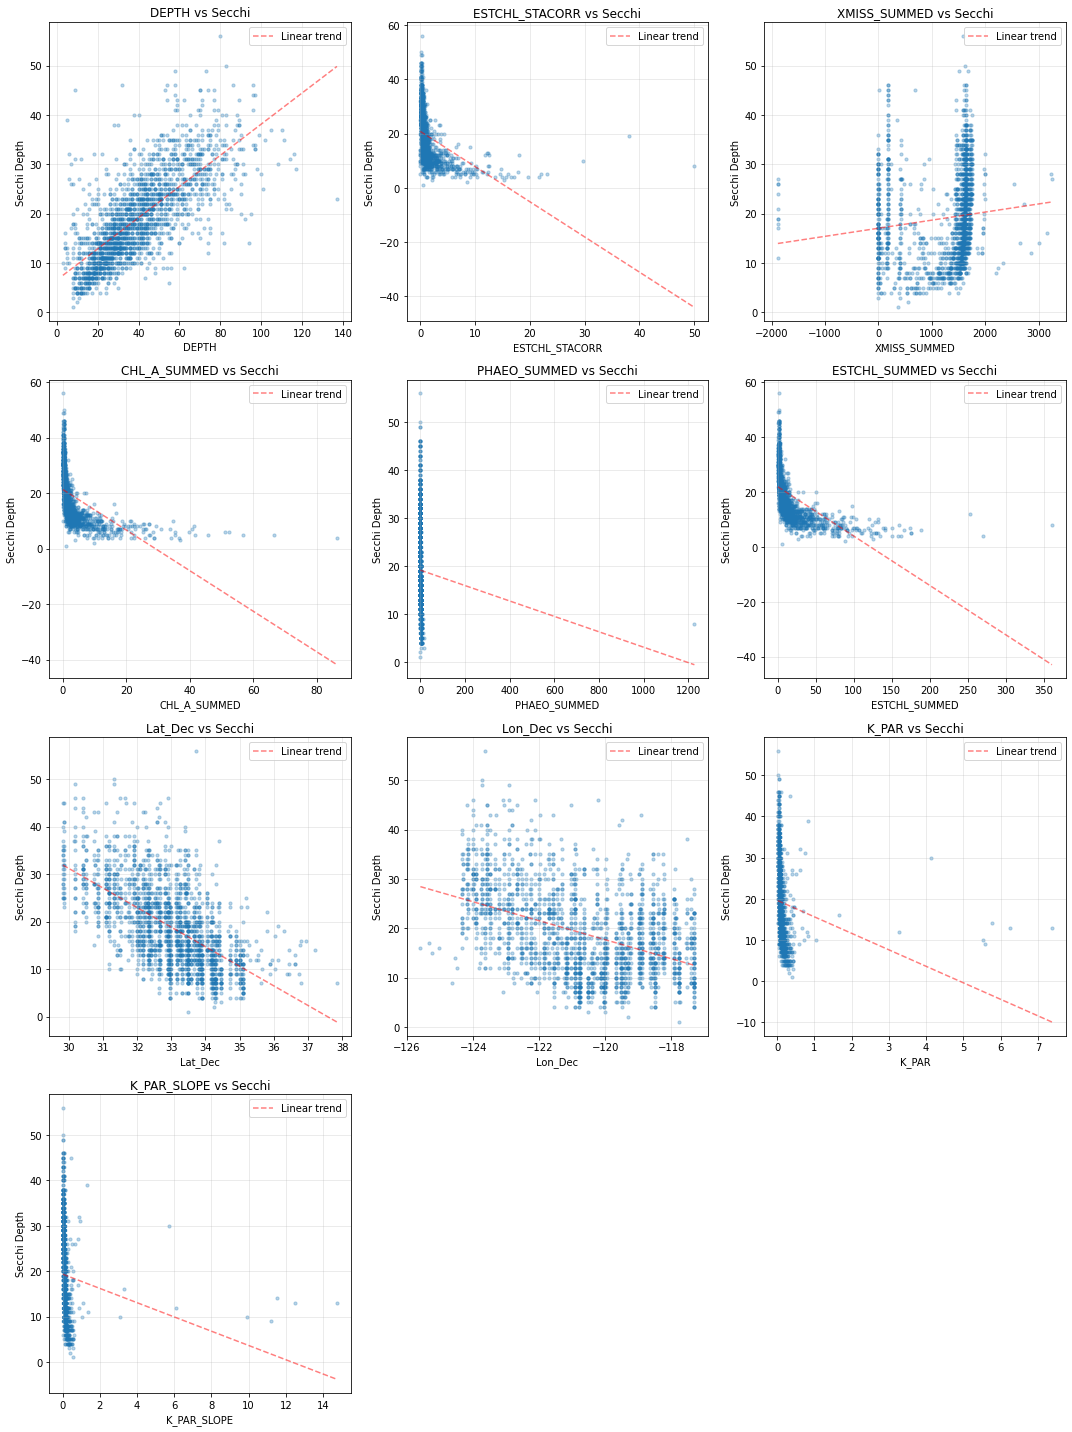

In [145]:
# Scatter plots for each predictor vs Secchi
n_vars = len(variables)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].scatter(df_clean[var], df_clean[target], alpha=0.3, s=10)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Secchi Depth')
    axes[i].set_title(f'{var} vs Secchi')
    
    # Add trend line
    z = np.polyfit(df_clean[var], df_clean[target], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_clean[var].min(), df_clean[var].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', alpha=0.5, label='Linear trend')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Remove extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

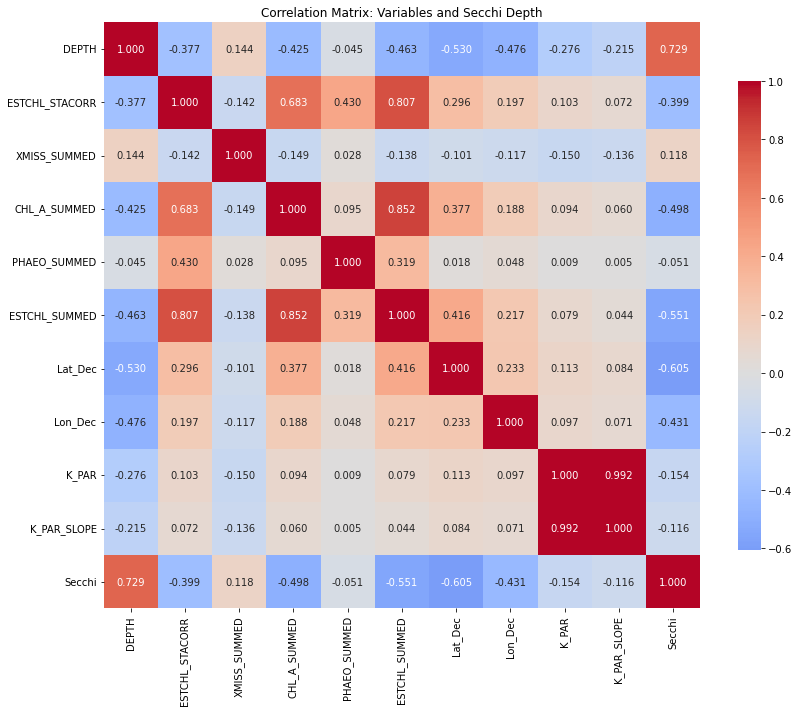


Correlations with Secchi depth:
Secchi            1.000000
DEPTH             0.728570
XMISS_SUMMED      0.117617
PHAEO_SUMMED     -0.050744
K_PAR_SLOPE      -0.116031
K_PAR            -0.154374
ESTCHL_STACORR   -0.398658
Lon_Dec          -0.430991
CHL_A_SUMMED     -0.497703
ESTCHL_SUMMED    -0.550824
Lat_Dec          -0.605069
Name: Secchi, dtype: float64


In [146]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix: Variables and Secchi Depth')
plt.tight_layout()
plt.show()

print("\nCorrelations with Secchi depth:")
print(df_clean.corr()[target].sort_values(ascending=False))

In [147]:
# =========================
# Step 2: Train/test split (excluding spatial variables for now)
# =========================

from sklearn.model_selection import train_test_split
import numpy as np

baseline_features = [
    'DEPTH',
    'ESTCHL_STACORR',
    'XMISS_SUMMED',
    'CHL_A_SUMMED',
    'PHAEO_SUMMED',
    'ESTCHL_SUMMED',
    'K_PAR',
    'K_PAR_SLOPE'
]

X = df_clean[baseline_features].values
y = df_clean[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])
print("X_train shape:   ", X_train.shape)  # should be (N, 8)

Training samples: 1570
Testing samples:  393
X_train shape:    (1570, 8)


In [148]:
# =========================
# Step 3: Baseline GAM (all smooth terms) (besides lat/lon)
# =========================

from pygam import LinearGAM, s
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

print("=" * 70)
print("GRID SEARCH FOR OPTIMAL SMOOTHING PENALTY")
print("=" * 70)

lams = np.logspace(-3, 5, 20)

print("\nPerforming grid search for optimal lambda...")
print("This may take a minute...\n")

gam_baseline = LinearGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7)
).gridsearch(X_train, y_train, lam=lams)

print("Optimal lambda values found:")
for i, var in enumerate(baseline_features):
    print(f"  {var:20s}: λ = {gam_baseline.lam[i][0]:.4f}")

print(f"\nTotal EDF: {gam_baseline.statistics_['edof']:.2f}")

# Per-term EDF breakdown
edof_per_coef = gam_baseline.statistics_['edof_per_coef']
edfs = []
current_idx = 0

for term in gam_baseline.terms:
    if term.isintercept:
        current_idx += 1
        continue
    n_coefs = term.n_coefs
    term_edf = edof_per_coef[current_idx:current_idx + n_coefs].sum()
    edfs.append(term_edf)
    current_idx += n_coefs

edfs = np.array(edfs)

print("\nIndividual term EDFs:\n")
for i, var in enumerate(baseline_features):
    edf = edfs[i]
    if edf < 1.5:
        interpretation = "LINEAR"
        recommendation = "Consider l()"
    elif edf < 3:
        interpretation = "MILDLY NON-LINEAR"
        recommendation = "Keep s()"
    else:
        interpretation = "STRONGLY NON-LINEAR"
        recommendation = "Keep s()"
    print(f"  {var:20s}: EDF = {edf:5.2f}  [{interpretation:20s}] → {recommendation}")

  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


GRID SEARCH FOR OPTIMAL SMOOTHING PENALTY

Performing grid search for optimal lambda...
This may take a minute...



  5% (1 of 20) |#                        | Elapsed Time: 0:00:00 ETA:   0:00:05
 10% (2 of 20) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:04
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:04
 20% (4 of 20) |#####                    | Elapsed Time: 0:00:01 ETA:   0:00:04
 25% (5 of 20) |######                   | Elapsed Time: 0:00:01 ETA:   0:00:03
 30% (6 of 20) |#######                  | Elapsed Time: 0:00:01 ETA:   0:00:03
 35% (7 of 20) |########                 | Elapsed Time: 0:00:01 ETA:   0:00:03
 40% (8 of 20) |##########               | Elapsed Time: 0:00:02 ETA:   0:00:03
 45% (9 of 20) |###########              | Elapsed Time: 0:00:02 ETA:   0:00:03
 50% (10 of 20) |############            | Elapsed Time: 0:00:02 ETA:   0:00:02
 55% (11 of 20) |#############           | Elapsed Time: 0:00:03 ETA:   0:00:02
 60% (12 of 20) |##############          | Elapsed Time: 0:00:03 ETA:   0:00:02
 65% (13 of 20) |###############        

Optimal lambda values found:
  DEPTH               : λ = 0.0483
  ESTCHL_STACORR      : λ = 0.0483
  XMISS_SUMMED        : λ = 0.0483
  CHL_A_SUMMED        : λ = 0.0483
  PHAEO_SUMMED        : λ = 0.0483
  ESTCHL_SUMMED       : λ = 0.0483
  K_PAR               : λ = 0.0483
  K_PAR_SLOPE         : λ = 0.0483

Total EDF: 65.88

Individual term EDFs:

  DEPTH               : EDF = 16.43  [STRONGLY NON-LINEAR ] → Keep s()
  ESTCHL_STACORR      : EDF =  9.76  [STRONGLY NON-LINEAR ] → Keep s()
  XMISS_SUMMED        : EDF = 10.85  [STRONGLY NON-LINEAR ] → Keep s()
  CHL_A_SUMMED        : EDF = 11.11  [STRONGLY NON-LINEAR ] → Keep s()
  PHAEO_SUMMED        : EDF =  1.06  [LINEAR              ] → Consider l()
  ESTCHL_SUMMED       : EDF =  7.44  [STRONGLY NON-LINEAR ] → Keep s()
  K_PAR               : EDF =  8.30  [STRONGLY NON-LINEAR ] → Keep s()
  K_PAR_SLOPE         : EDF =  0.93  [LINEAR              ] → Consider l()


PHAEO_SUMMED and K_PAR_SLOPE are nonlinear?

In [149]:
# =========================
# Step 4: Evaluate baseline model
# =========================

from sklearn.metrics import r2_score, mean_squared_error

y_train_pred = gam_baseline.predict(X_train)
y_test_pred  = gam_baseline.predict(X_test)

train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))

print(f"Training R²:   {train_r2:.4f}")
print(f"Test R²:       {test_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test RMSE:     {test_rmse:.4f}")

Training R²:   0.7753
Test R²:       0.7084
Training RMSE: 4.1743
Test RMSE:     4.6380


In [150]:
# =========================
# Step 4.5: Cross-validate baseline model
# =========================

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np
from pygam import LinearGAM, s, l

def evaluate_gam(features):

    X = df_clean[features].values
    y = df_clean[target].values

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = []

    for train_idx, test_idx in kf.split(X):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Build GAM terms
        terms = None
        for i, feature in enumerate(features):

            if feature in ['PHAEO_SUMMED', 'K_PAR_SLOPE']:
                term = l(i) # These two features had low EDF in the previous analysis, so we use linear terms for them
            else:
                term = s(i)

            terms = term if terms is None else terms + term

        gam = LinearGAM(terms)
        gam.gridsearch(X_train, y_train, progress=False)

        pred = gam.predict(X_test)
        scores.append(r2_score(y_test, pred))

    return np.mean(scores), np.std(scores)


baseline_features = [
    'DEPTH',
    'ESTCHL_STACORR',
    'XMISS_SUMMED',
    'CHL_A_SUMMED',
    'PHAEO_SUMMED',
    'ESTCHL_SUMMED',
    'K_PAR',
    'K_PAR_SLOPE'
]

mean_r2, std_r2 = evaluate_gam(baseline_features)

print("Baseline GAM CV performance")
print("Features:", baseline_features)
print(f"CV R²: {mean_r2:.4f} ± {std_r2:.4f}")

Baseline GAM CV performance
Features: ['DEPTH', 'ESTCHL_STACORR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'ESTCHL_SUMMED', 'K_PAR', 'K_PAR_SLOPE']
CV R²: 0.7348 ± 0.0357


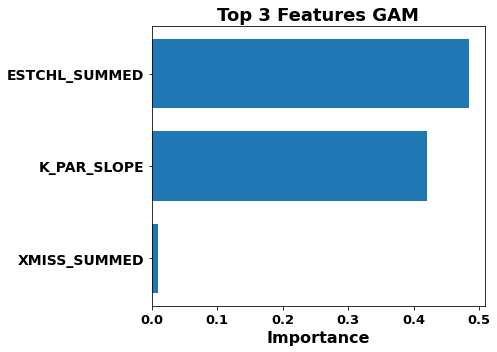

In [52]:
# Plot feature importance (selected features only)
import matplotlib.pyplot as plt

plot_df = importance_df[importance_df["feature"].isin(['ESTCHL_SUMMED', 'K_PAR_SLOPE', 'XMISS_SUMMED'])]

plt.figure(figsize=(7, 5))
plt.barh(
    range(len(plot_df)),
    plot_df["importance"],
    height=0.75
)
plt.yticks(
    range(len(plot_df)),
    plot_df["feature"],
    fontsize=14,
    fontweight='bold'
)
plt.xticks(
    fontsize=13,
    fontweight='bold'
)
plt.xlabel(
    "Importance",
    fontsize=16,
    fontweight='bold'
)
plt.title(
    "Top 3 Features GAM",
    fontsize=18,
    fontweight='bold'
)
plt.gca().invert_yaxis()
plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
plt.tight_layout()
plt.show()

In [152]:
# =========================
# Step 6: Cross-validation function for GAM models (already defined above evaluate_gam)
# =========================

In [153]:
# =========================
# Step 7: Test K_PAR vs K_PAR_SLOPE
# =========================

models = {
    "KPAR only": ["ESTCHL_SUMMED","K_PAR","XMISS_SUMMED"],
    "KPAR_SLOPE only": ["ESTCHL_SUMMED","K_PAR_SLOPE","XMISS_SUMMED"],
    "Both": ["ESTCHL_SUMMED","K_PAR","K_PAR_SLOPE","XMISS_SUMMED"]}

for name, features in models.items():

    mean_r2, std_r2 = evaluate_gam(features)

    print(name)
    print("Features:", features)
    print(f"CV R²: {mean_r2:.4f} ± {std_r2:.4f}\n")

KPAR only
Features: ['ESTCHL_SUMMED', 'K_PAR', 'XMISS_SUMMED']
CV R²: 0.7193 ± 0.0264

KPAR_SLOPE only
Features: ['ESTCHL_SUMMED', 'K_PAR_SLOPE', 'XMISS_SUMMED']
CV R²: 0.7048 ± 0.0269

Both
Features: ['ESTCHL_SUMMED', 'K_PAR', 'K_PAR_SLOPE', 'XMISS_SUMMED']
CV R²: 0.7186 ± 0.0286



Both K_PAR AND K_PAR_SLOPE were pretty important (see variable importance plot). Improvement from including both is tiny.

In [154]:
# =========================
# Step 8: Compare candidate models (≤5 predictors)
# =========================

candidate_models = {
    "Top 3": ["ESTCHL_SUMMED","K_PAR","XMISS_SUMMED"],
    "Top 4": ["ESTCHL_SUMMED","K_PAR","K_PAR_SLOPE","XMISS_SUMMED"],
    "Top 5": ["ESTCHL_SUMMED","K_PAR","K_PAR_SLOPE","XMISS_SUMMED","CHL_A_SUMMED"]
}

for name, features in candidate_models.items():

    mean_r2, std_r2 = evaluate_gam(features)

    print(name)
    print("Features:", features)
    print(f"CV R²: {mean_r2:.4f} ± {std_r2:.4f}\n")

Top 3
Features: ['ESTCHL_SUMMED', 'K_PAR', 'XMISS_SUMMED']
CV R²: 0.7193 ± 0.0264

Top 4
Features: ['ESTCHL_SUMMED', 'K_PAR', 'K_PAR_SLOPE', 'XMISS_SUMMED']
CV R²: 0.7186 ± 0.0286

Top 5
Features: ['ESTCHL_SUMMED', 'K_PAR', 'K_PAR_SLOPE', 'XMISS_SUMMED', 'CHL_A_SUMMED']
CV R²: 0.7325 ± 0.0280



Performance is roughly similar for all three models, so going with the simplest model is a good choice, since the model with the best performance also includes two chlorophyll and two k_par predictors.


In [155]:
# =========================
# Step 9: Fit final GAM
# =========================

final_features = [
    "ESTCHL_SUMMED",
    "K_PAR",
    "XMISS_SUMMED",
]

X_final = df_clean[final_features].values
y_final = df_clean[target].values

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

from pygam import LinearGAM, s

gam_final = LinearGAM(s(0) + s(1) + s(2))
gam_final.gridsearch(X_train_final, y_train_final)

print("Total EDF:", gam_final.statistics_['edof'])

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:01 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:01


Total EDF: 33.69540609358723


In [156]:
# =========================
# Step 10: Inspect EDFs and model summary
# =========================
print(gam_final.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     33.6954
Link Function:                     IdentityLink Log Likelihood:                                  -6178.577
Number of Samples:                         1570 AIC:                                            12426.5448
                                                AICc:                                           12428.1592
                                                GCV:                                               20.7226
                                                Scale:                                             19.9236
                                                Pseudo R-Squared:                                   0.7485
Feature Function                  Lam

/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_1791/1267267591.py:4: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_final.summary())


EDF value interpretation:
EDF ≈ 1 → linear
EDF 1–3 → mild curvature
EDF > 3 → nonlinear
EDF > 6 → strongly nonlinear

Keep these three predictors as nonlinear splines, since EDFs are from 9-13.

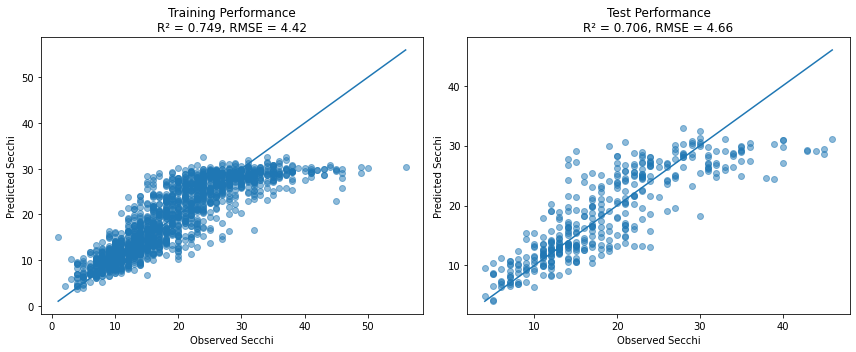

In [157]:
# =========================
# Step 11: Model Performance Plots (Training + Testing)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Generate predictions
y_train_pred_final = gam_final.predict(X_train_final)
y_test_pred_final  = gam_final.predict(X_test_final)

# Calculate metrics
train_r2   = r2_score(y_train_final, y_train_pred_final)
test_r2    = r2_score(y_test_final,  y_test_pred_final)
train_rmse = np.sqrt(mean_squared_error(y_train_final, y_train_pred_final))
test_rmse  = np.sqrt(mean_squared_error(y_test_final,  y_test_pred_final))

# Create plots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(y_train_final, y_train_pred_final, alpha=0.5)
axs[0].plot([y_train_final.min(), y_train_final.max()],
            [y_train_final.min(), y_train_final.max()])
axs[0].set_title(f"Training Performance\nR² = {train_r2:.3f}, RMSE = {train_rmse:.2f}")
axs[0].set_xlabel("Observed Secchi")
axs[0].set_ylabel("Predicted Secchi")

axs[1].scatter(y_test_final, y_test_pred_final, alpha=0.5)
axs[1].plot([y_test_final.min(), y_test_final.max()],
            [y_test_final.min(), y_test_final.max()])
axs[1].set_title(f"Test Performance\nR² = {test_r2:.3f}, RMSE = {test_rmse:.2f}")
axs[1].set_xlabel("Observed Secchi")
axs[1].set_ylabel("Predicted Secchi")

plt.tight_layout()
plt.show()

# Compare top 3 model to spatial model
# Secchi ~ s(ESTCHL_SUMMED) + s(K_PAR) + s(DEPTH) + te(Lon_Dec, Lat_Dec)

In [158]:
# =========================
# Step 12: Spatial GAM comparison
# =========================

from pygam import LinearGAM, s, te

# include spatial coordinates
spatial_features = [
    "ESTCHL_SUMMED",
    "K_PAR",
    "DEPTH",
    "Lon_Dec",
    "Lat_Dec"
]

X_spatial = df_clean[spatial_features].values
y_spatial = df_clean[target].values

from sklearn.model_selection import train_test_split

X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_spatial,
    y_spatial,
    test_size=0.2,
    random_state=42
)

# GAM with spatial tensor
gam_spatial = LinearGAM(
    s(0) + s(1) + s(2) + te(3,4)
)

gam_spatial.gridsearch(X_train_sp, y_train_sp)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:06
 18% (2 of 11) |####                     | Elapsed Time: 0:00:01 ETA:   0:00:04
 27% (3 of 11) |######                   | Elapsed Time: 0:00:01 ETA:   0:00:04
 36% (4 of 11) |#########                | Elapsed Time: 0:00:02 ETA:   0:00:03
 45% (5 of 11) |###########              | Elapsed Time: 0:00:02 ETA:   0:00:03
 54% (6 of 11) |#############            | Elapsed Time: 0:00:03 ETA:   0:00:02
 63% (7 of 11) |###############          | Elapsed Time: 0:00:03 ETA:   0:00:02
 72% (8 of 11) |##################       | Elapsed Time: 0:00:04 ETA:   0:00:01
 81% (9 of 11) |####################     | Elapsed Time: 0:00:04 ETA:   0:00:01
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:05 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:06 Time:  0:00:06


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + s(1) + s(2) + te(3, 4) + intercept, tol=0.0001, 
   verbose=False)

In [159]:
# =========================
# Step 13: Evaluate spatial GAM performance
# =========================

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_train_pred_sp = gam_spatial.predict(X_train_sp)
y_test_pred_sp = gam_spatial.predict(X_test_sp)

train_r2_sp = r2_score(y_train_sp, y_train_pred_sp)
test_r2_sp = r2_score(y_test_sp, y_test_pred_sp)

train_rmse_sp = np.sqrt(mean_squared_error(y_train_sp, y_train_pred_sp))
test_rmse_sp = np.sqrt(mean_squared_error(y_test_sp, y_test_pred_sp))

print("Spatial Model Performance")
print("Training R²:", round(train_r2_sp,4))
print("Test R²:", round(test_r2_sp,4))
print("Training RMSE:", round(train_rmse_sp,4))
print("Test RMSE:", round(test_rmse_sp,4))

Spatial Model Performance
Training R²: 0.7679
Test R²: 0.7054
Training RMSE: 4.2418
Test RMSE: 4.6622


In [160]:
# =========================
# Step 14: Cross-validate spatial GAM
# =========================

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from pygam import LinearGAM, s, te
import numpy as np

features_spatial = [
    "ESTCHL_SUMMED",
    "K_PAR",
    "DEPTH",
    "Lon_Dec",
    "Lat_Dec"
]

X_sp = df_clean[features_spatial].values
y_sp = df_clean[target].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

sp_scores = []

for train_idx, test_idx in kf.split(X_sp):

    X_tr_sp, X_te_sp = X_sp[train_idx], X_sp[test_idx]
    y_tr_sp, y_te_sp = y_sp[train_idx], y_sp[test_idx]

    gam_spatial_cv = LinearGAM(s(0) + s(1) + s(2) + te(3, 4))
    gam_spatial_cv.gridsearch(X_tr_sp, y_tr_sp, progress=False)

    preds = gam_spatial_cv.predict(X_te_sp)
    sp_scores.append(r2_score(y_te_sp, preds))

sp_scores = np.array(sp_scores)

print("Spatial GAM CV Performance")
print("Mean CV R²:", round(sp_scores.mean(), 4))
print("Std CV R²:",  round(sp_scores.std(),  4))

Spatial GAM CV Performance
Mean CV R²: 0.7348
Std CV R²: 0.0255


Spatial model CV test R^2 is 0.0046 higher than the top 3 model. Very similar performance.

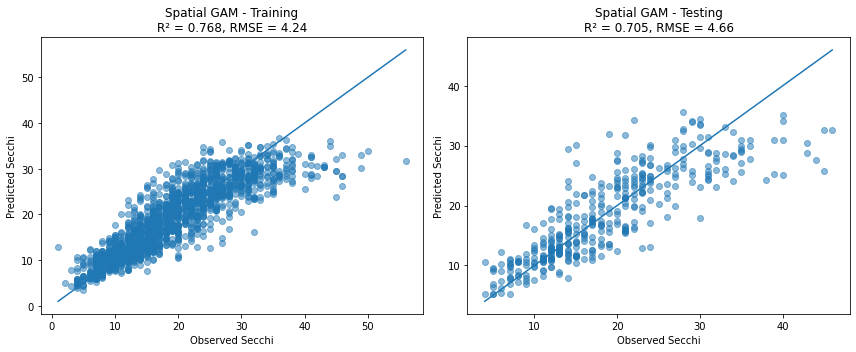

In [161]:
# =========================
# Spatial GAM Performance Plots
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Predictions
y_train_pred_sp = gam_spatial.predict(X_train_sp)
y_test_pred_sp = gam_spatial.predict(X_test_sp)

# Metrics
train_r2_sp = r2_score(y_train_sp, y_train_pred_sp)
test_r2_sp = r2_score(y_test_sp, y_test_pred_sp)

train_rmse_sp = np.sqrt(mean_squared_error(y_train_sp, y_train_pred_sp))
test_rmse_sp = np.sqrt(mean_squared_error(y_test_sp, y_test_pred_sp))

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# Training plot
axs[0].scatter(y_train_sp, y_train_pred_sp, alpha=0.5)
axs[0].plot(
    [y_train_sp.min(), y_train_sp.max()],
    [y_train_sp.min(), y_train_sp.max()]
)
axs[0].set_title(f"Spatial GAM - Training\nR² = {train_r2_sp:.3f}, RMSE = {train_rmse_sp:.2f}")
axs[0].set_xlabel("Observed Secchi")
axs[0].set_ylabel("Predicted Secchi")

# Test plot
axs[1].scatter(y_test_sp, y_test_pred_sp, alpha=0.5)
axs[1].plot(
    [y_test_sp.min(), y_test_sp.max()],
    [y_test_sp.min(), y_test_sp.max()]
)
axs[1].set_title(f"Spatial GAM - Testing\nR² = {test_r2_sp:.3f}, RMSE = {test_rmse_sp:.2f}")
axs[1].set_xlabel("Observed Secchi")
axs[1].set_ylabel("Predicted Secchi")

plt.tight_layout()
plt.show()

# Compare various different GAM models side by side using New_estchlsummed.parquet 
## Uses linear function for PHAEO_SUMMED and K_PAR_SLOPE (as found by EDF analysis from baseline model), and spline function for all other predictors using evaluate_gam()
## Produces train, test, and CV ^2 as well as RSME


Model: ESTCHL_SUMMED + K_PAR_SLOPE + DEPTH
                       R²       RMSE
  Train            0.7491     4.3740
  Test             0.7056     4.7791
  CV (mean)        0.7233     4.5963
  CV (std)         0.0157     0.2357

Model: ESTCHL_SUMMED + K_PAR_SLOPE + XMISS_SUMMED
                       R²       RMSE
  Train            0.7222     4.6025
  Test             0.6829     4.9604
  CV (mean)        0.7001     4.7852
  CV (std)         0.0156     0.2330

Model: K_PAR_SLOPE + DEPTH + XMISS_SUMMED
                       R²       RMSE
  Train            0.6073     5.4723
  Test             0.5212     6.0950
  CV (mean)        0.5698     5.7275
  CV (std)         0.0283     0.2438

Model: ESTCHL_SUMMED + K_PAR_SLOPE + DEPTH + XMISS_SUMMED
                       R²       RMSE
  Train            0.7559     4.3144
  Test             0.7103     4.7412
  CV (mean)        0.7257     4.5767
  CV (std)         0.0189     0.2699


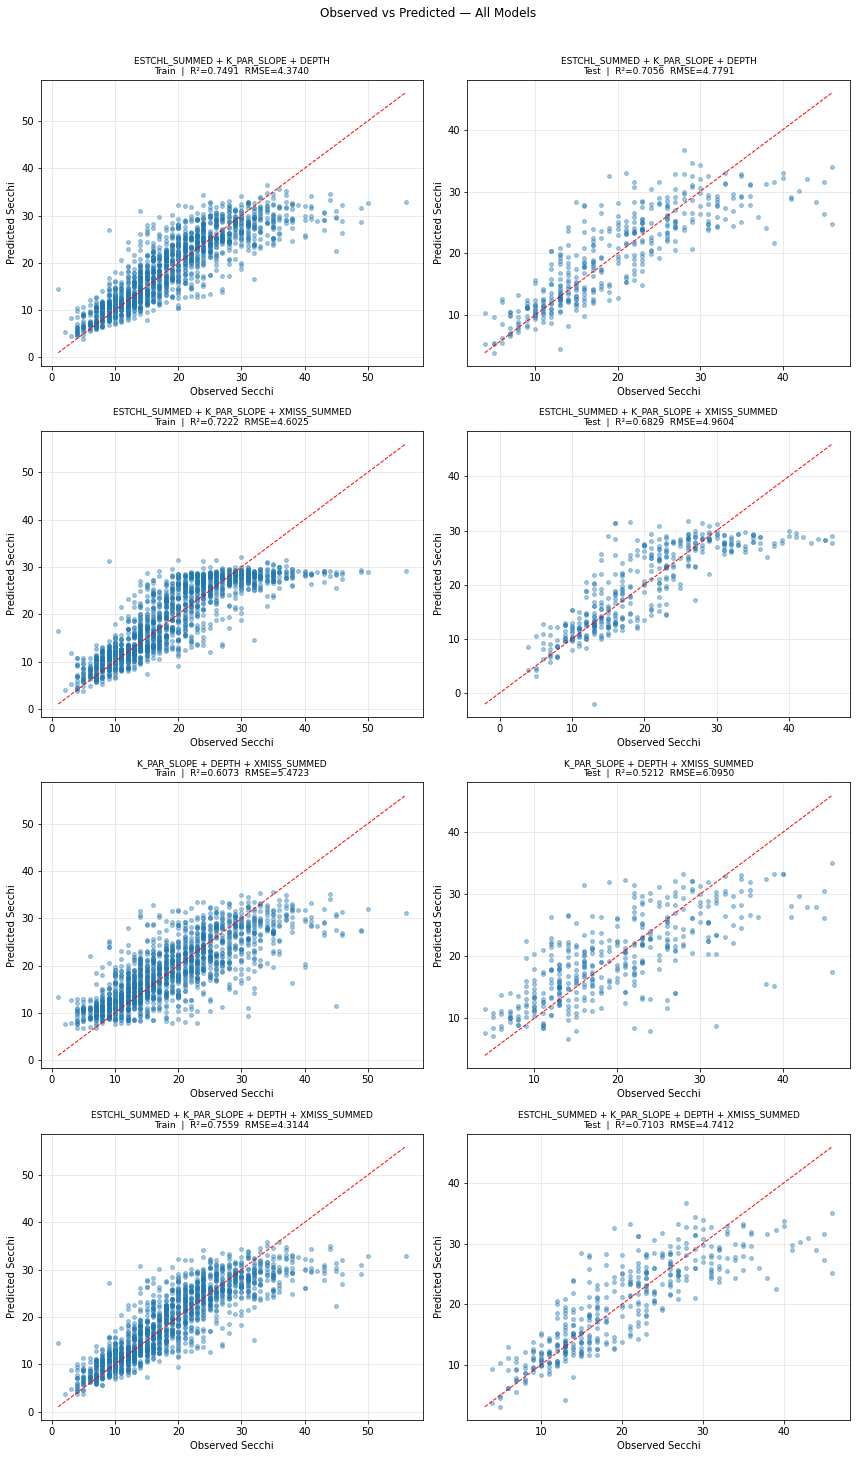

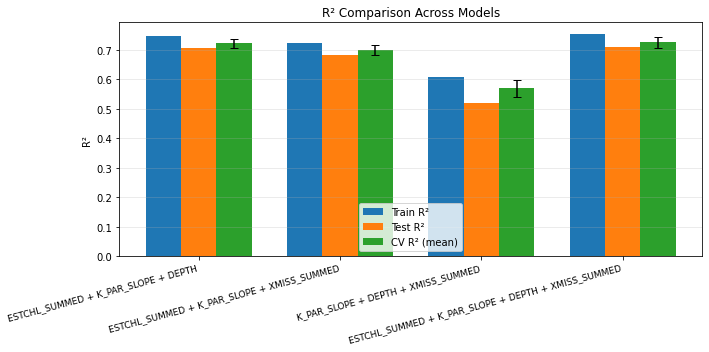

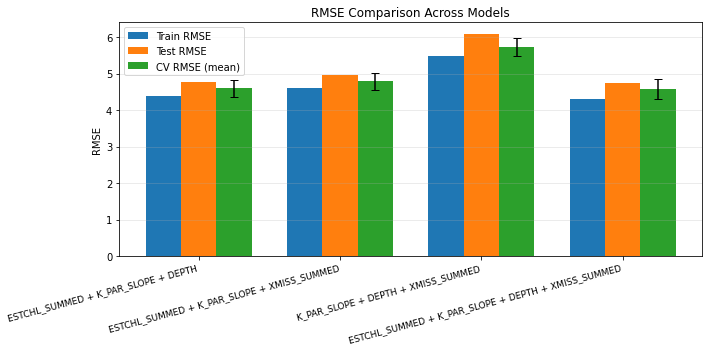

In [165]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s, l
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error

# =========================
# Load and clean data
# =========================
df = pd.read_parquet("../data/Parquet/New_estchlsummed.parquet")
target = 'Secchi'

candidate_models = {
    # 3 predictor models (keep K_PAR and K_PAR_SLOPE separate to avoid multicollinearity)
    # Only K_PAR_SLOPE here since the next code chunk is for all spline terms and will be redundant for models w/o K_PAR_SLOPE
    "ESTCHL_SUMMED + K_PAR_SLOPE + DEPTH": [
        "ESTCHL_SUMMED", "K_PAR_SLOPE", "DEPTH"
    ],
    "ESTCHL_SUMMED + K_PAR_SLOPE + XMISS_SUMMED": [
        "ESTCHL_SUMMED", "K_PAR_SLOPE", "XMISS_SUMMED"
    ],
    "K_PAR_SLOPE + DEPTH + XMISS_SUMMED": [
        "K_PAR_SLOPE", "DEPTH", "XMISS_SUMMED"
    ],
    # 4 predictor models (K_PAR & K_PAR_SLOPE are never together in 4-predictor models to avoid multicollinearity)
    "ESTCHL_SUMMED + K_PAR_SLOPE + DEPTH + XMISS_SUMMED": [
        "ESTCHL_SUMMED", "K_PAR_SLOPE", "DEPTH", "XMISS_SUMMED"
    ],
}

# Features treated as linear based on EDF analysis (EDF near 1 in baseline model)
LINEAR_FEATURES = ['PHAEO_SUMMED', 'K_PAR_SLOPE']

# =========================
# Helper: build GAM terms respecting l() vs s()
# =========================
def build_terms(features):
    terms = None
    for i, feature in enumerate(features):
        term = l(i) if feature in LINEAR_FEATURES else s(i)
        terms = term if terms is None else terms + term
    return terms

# =========================
# Helper: cross-validate a GAM (all splines)
# =========================
def evaluate_gam_all_splines(df_clean, features, target, n_splits=5, random_state=42):
    X = df_clean[features].values
    y = df_clean[target].values

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores, rmse_scores = [], []

    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        terms = s(0)
        for i in range(1, len(features)):
            terms += s(i)

        gam = LinearGAM(terms)
        gam.gridsearch(X_tr, y_tr, progress=False)
        preds = gam.predict(X_te)
        r2_scores.append(r2_score(y_te, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_te, preds)))

    return (np.mean(r2_scores), np.std(r2_scores),
            np.mean(rmse_scores), np.std(rmse_scores))

# =========================
# Helper: cross-validate a GAM (l() for linear features, s() for rest)
# =========================
def evaluate_gam(df_clean, features, target, n_splits=5, random_state=42):
    X = df_clean[features].values
    y = df_clean[target].values

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores, rmse_scores = [], []

    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        gam = LinearGAM(build_terms(features))
        gam.gridsearch(X_tr, y_tr, progress=False)
        preds = gam.predict(X_te)
        r2_scores.append(r2_score(y_te, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_te, preds)))

    return (np.mean(r2_scores), np.std(r2_scores),
            np.mean(rmse_scores), np.std(rmse_scores))

import matplotlib.pyplot as plt

# =========================
# Run models + collect results
# =========================
results = {}

for name, features in candidate_models.items():
    all_cols = features + [target]
    df_clean = df[all_cols].dropna().copy()

    X = df_clean[features].values
    y = df_clean[target].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    gam = LinearGAM(build_terms(features))
    gam.gridsearch(X_train, y_train, progress=False)

    y_train_pred = gam.predict(X_train)
    y_test_pred  = gam.predict(X_test)

    train_r2   = r2_score(y_train, y_train_pred)
    test_r2    = r2_score(y_test,  y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))

    cv_r2_mean, cv_r2_std, cv_rmse_mean, cv_rmse_std = evaluate_gam(df_clean, features, target)

    print(f"\nModel: {name}")
    print(f"  {'':12} {'R²':>10} {'RMSE':>10}")
    print(f"  {'Train':12} {train_r2:>10.4f} {train_rmse:>10.4f}")
    print(f"  {'Test':12} {test_r2:>10.4f} {test_rmse:>10.4f}")
    print(f"  {'CV (mean)':12} {cv_r2_mean:>10.4f} {cv_rmse_mean:>10.4f}")
    print(f"  {'CV (std)':12} {cv_r2_std:>10.4f} {cv_rmse_std:>10.4f}")

    results[name] = dict(
        train_r2=train_r2, test_r2=test_r2,
        train_rmse=train_rmse, test_rmse=test_rmse,
        cv_r2_mean=cv_r2_mean, cv_r2_std=cv_r2_std,
        cv_rmse_mean=cv_rmse_mean, cv_rmse_std=cv_rmse_std,
        y_train=y_train, y_train_pred=y_train_pred,
        y_test=y_test,  y_test_pred=y_test_pred,
    )

# =========================
# Plots
# =========================
n_models = len(results)
model_names = list(results.keys())

# --- 1. Observed vs Predicted (train + test per model) ---
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))
if n_models == 1:
    axes = [axes]

for row, (name, r) in enumerate(results.items()):
    for col, (split, y_obs, y_pred) in enumerate([
        ("Train", r['y_train'], r['y_train_pred']),
        ("Test",  r['y_test'],  r['y_test_pred']),
    ]):
        ax = axes[row][col]
        ax.scatter(y_obs, y_pred, alpha=0.4, s=15)
        lim = [min(y_obs.min(), y_pred.min()), max(y_obs.max(), y_pred.max())]
        ax.plot(lim, lim, 'r--', linewidth=1)
        r2   = r[f"{split.lower()}_r2"]
        rmse = r[f"{split.lower()}_rmse"]
        ax.set_title(f"{name}\n{split}  |  R²={r2:.4f}  RMSE={rmse:.4f}", fontsize=9)
        ax.set_xlabel("Observed Secchi")
        ax.set_ylabel("Predicted Secchi")
        ax.grid(True, alpha=0.3)

plt.suptitle("Observed vs Predicted — All Models", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# --- 2. R² comparison bar chart (train / test / CV) ---
x = np.arange(n_models)
width = 0.25

fig, ax = plt.subplots(figsize=(max(7, n_models * 2.5), 5))
ax.bar(x - width, [results[n]['train_r2']   for n in model_names], width, label='Train R²')
ax.bar(x,         [results[n]['test_r2']    for n in model_names], width, label='Test R²')
ax.bar(x + width, [results[n]['cv_r2_mean'] for n in model_names], width, label='CV R² (mean)',
       yerr=[results[n]['cv_r2_std'] for n in model_names], capsize=4)

ax.set_ylabel("R²")
ax.set_title("R² Comparison Across Models")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. RMSE comparison bar chart (train / test / CV) ---
fig, ax = plt.subplots(figsize=(max(7, n_models * 2.5), 5))
ax.bar(x - width, [results[n]['train_rmse']   for n in model_names], width, label='Train RMSE')
ax.bar(x,         [results[n]['test_rmse']    for n in model_names], width, label='Test RMSE')
ax.bar(x + width, [results[n]['cv_rmse_mean'] for n in model_names], width, label='CV RMSE (mean)',
       yerr=[results[n]['cv_rmse_std'] for n in model_names], capsize=4)

ax.set_ylabel("RMSE")
ax.set_title("RMSE Comparison Across Models")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Compare various different GAM models side by side using New_estchlsummed.parquet 
## Uses spline function for all predictors evaluat_gam_all_splines()
## Produces train, test, and CV ^2 as well as RSME


Model: ESTCHL_SUMMED + K_PAR + XMISS_SUMMED
                       R²       RMSE
  Train            0.7420     4.4356
  Test             0.7033     4.7979
  CV (mean)        0.7164     4.6534
  CV (std)         0.0209     0.2838

Model: ESTCHL_SUMMED + K_PAR + DEPTH
                       R²       RMSE
  Train            0.7509     4.3583
  Test             0.7094     4.7482
  CV (mean)        0.7261     4.5729
  CV (std)         0.0143     0.2246

Model: K_PAR + DEPTH + XMISS_SUMMED
                       R²       RMSE
  Train            0.6107     5.4487
  Test             0.5184     6.1131
  CV (mean)        0.5691     5.7298
  CV (std)         0.0341     0.2562

Model: ESTCHL_SUMMED + K_PAR_SLOPE + DEPTH
                       R²       RMSE
  Train            0.7530     4.3398
  Test             0.7120     4.7269
  CV (mean)        0.7223     4.6050
  CV (std)         0.0147     0.2330

Model: ESTCHL_SUMMED + K_PAR_SLOPE + XMISS_SUMMED
                       R²       RMSE
  Train 

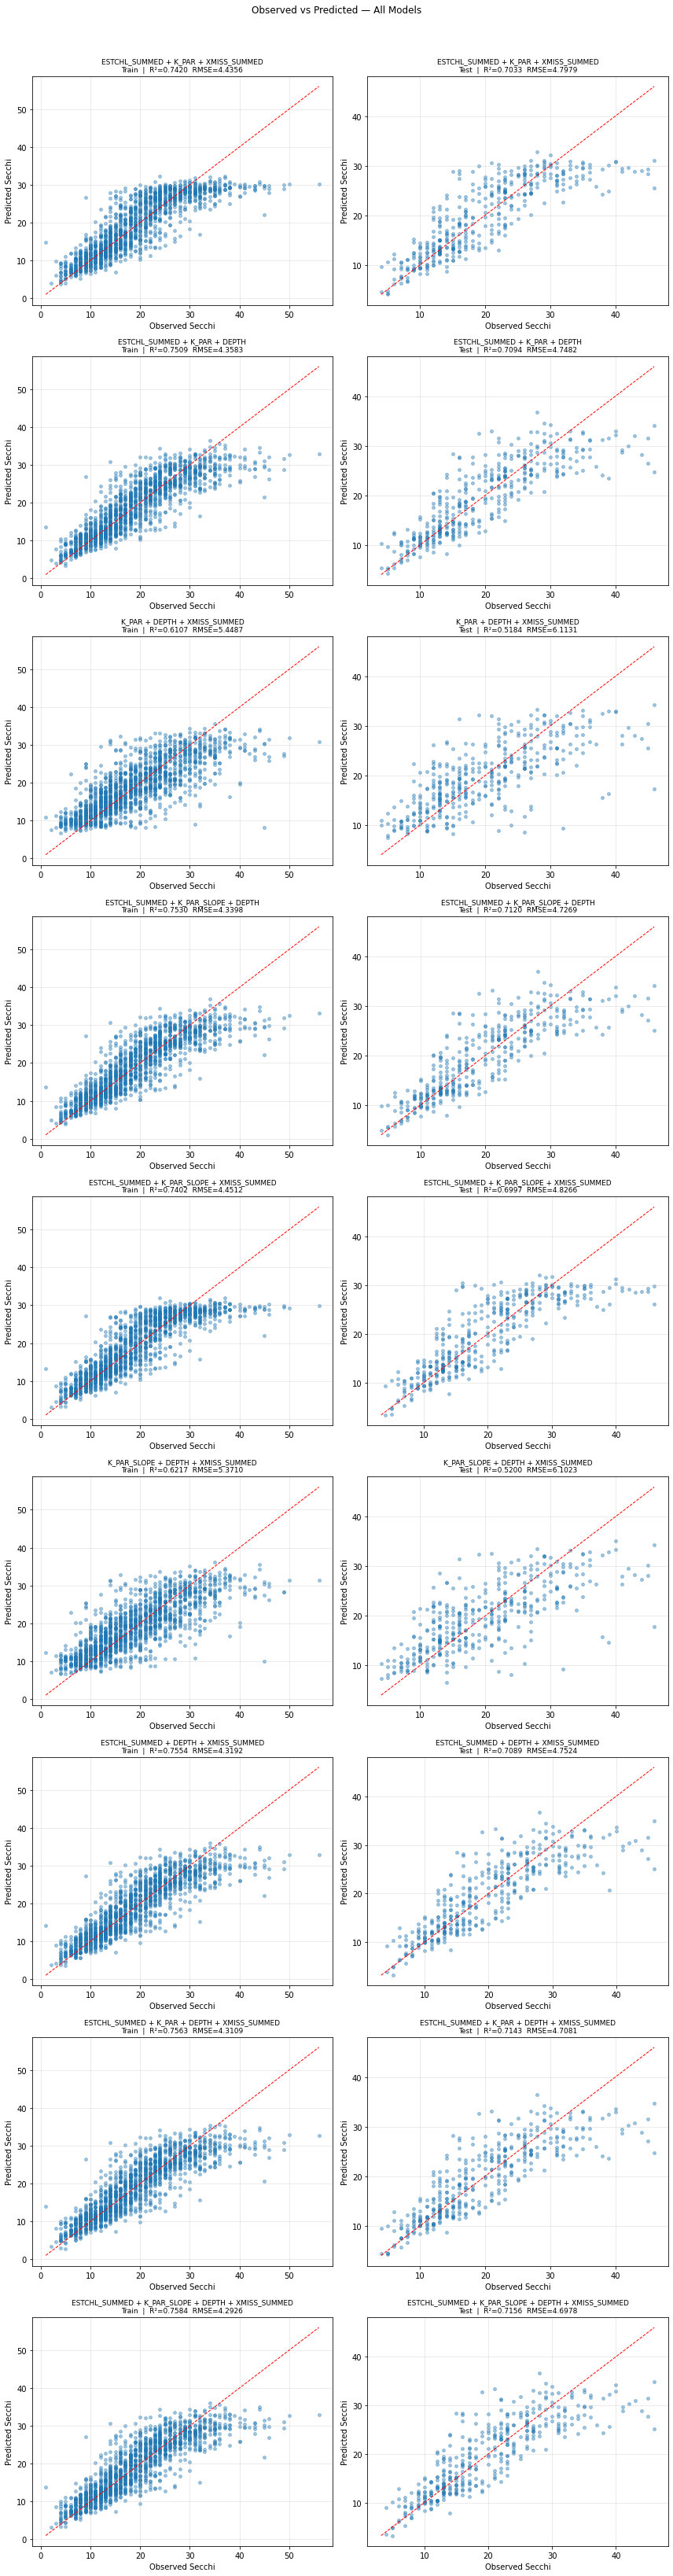

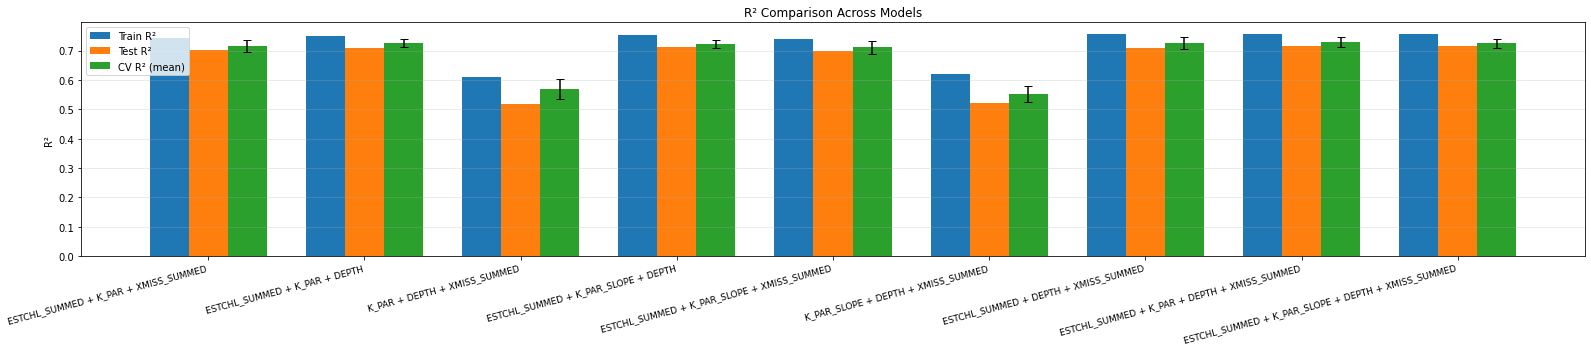

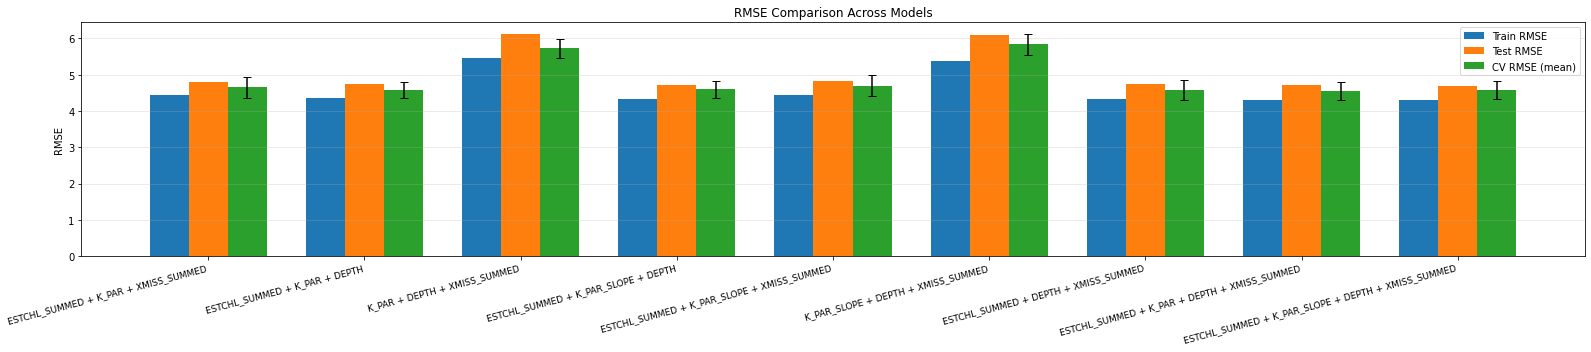

In [166]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error

# =========================
# Load and clean data
# =========================
df = pd.read_parquet("../data/Parquet/New_estchlsummed.parquet")
target = 'Secchi'

candidate_models = {
    # 3 predictor models (keep K_PAR and K_PAR_SLOPE separate to avoid multicollinearity)
    "ESTCHL_SUMMED + K_PAR + XMISS_SUMMED": [
        "ESTCHL_SUMMED", "K_PAR", "XMISS_SUMMED"
    ],
    "ESTCHL_SUMMED + K_PAR + DEPTH": [
        "ESTCHL_SUMMED", "K_PAR", "DEPTH"
    ],
    "K_PAR + DEPTH + XMISS_SUMMED": [
        "K_PAR", "DEPTH", "XMISS_SUMMED"
    ],
    "ESTCHL_SUMMED + K_PAR_SLOPE + DEPTH": [
        "ESTCHL_SUMMED", "K_PAR_SLOPE", "DEPTH"
    ],
    "ESTCHL_SUMMED + K_PAR_SLOPE + XMISS_SUMMED": [
        "ESTCHL_SUMMED", "K_PAR_SLOPE", "XMISS_SUMMED"
    ],
    "K_PAR_SLOPE + DEPTH + XMISS_SUMMED": [
        "K_PAR_SLOPE", "DEPTH", "XMISS_SUMMED"
    ],
    # No K_PAR or K_PAR_SLOPE
    "ESTCHL_SUMMED + DEPTH + XMISS_SUMMED": [
        "ESTCHL_SUMMED", "DEPTH", "XMISS_SUMMED"
    ],
    # 4 predictor models (K_PAR & K_PAR_SLOPE are never together in 4-predictor models to avoid multicollinearity)
    "ESTCHL_SUMMED + K_PAR + DEPTH + XMISS_SUMMED": [
        "ESTCHL_SUMMED", "K_PAR", "DEPTH", "XMISS_SUMMED"
    ],

    "ESTCHL_SUMMED + K_PAR_SLOPE + DEPTH + XMISS_SUMMED": [
        "ESTCHL_SUMMED", "K_PAR_SLOPE", "DEPTH", "XMISS_SUMMED"
    ],

}

# =========================
# Helper: cross-validate a GAM
# =========================
def evaluate_gam_all_splines(df_clean, features, target, n_splits=5, random_state=42):
    X = df_clean[features].values
    y = df_clean[target].values

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores, rmse_scores = [], []

    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        terms = s(0)
        for i in range(1, len(features)):
            terms += s(i) # all predictors are assumed to be splines.
            
        gam = LinearGAM(terms)
        gam.gridsearch(X_tr, y_tr, progress=False)
        preds = gam.predict(X_te)
        r2_scores.append(r2_score(y_te, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_te, preds)))

    return (np.mean(r2_scores), np.std(r2_scores),
            np.mean(rmse_scores), np.std(rmse_scores))

import matplotlib.pyplot as plt

# =========================
# Run models + collect results. Treats all predictors as splines based on previous EDF analysis, but this can be adjusted if desired.
# =========================
results = {}

for name, features in candidate_models.items():
    all_cols = features + [target]
    df_clean = df[all_cols].dropna().copy()

    X = df_clean[features].values
    y = df_clean[target].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    terms = s(0)
    for i in range(1, len(features)):
        terms += s(i)

    gam = LinearGAM(terms)
    gam.gridsearch(X_train, y_train, progress=False)

    y_train_pred = gam.predict(X_train)
    y_test_pred  = gam.predict(X_test)

    train_r2   = r2_score(y_train, y_train_pred)
    test_r2    = r2_score(y_test,  y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))

    cv_r2_mean, cv_r2_std, cv_rmse_mean, cv_rmse_std = evaluate_gam_all_splines(df_clean, features, target)

    print(f"\nModel: {name}")
    print(f"  {'':12} {'R²':>10} {'RMSE':>10}")
    print(f"  {'Train':12} {train_r2:>10.4f} {train_rmse:>10.4f}")
    print(f"  {'Test':12} {test_r2:>10.4f} {test_rmse:>10.4f}")
    print(f"  {'CV (mean)':12} {cv_r2_mean:>10.4f} {cv_rmse_mean:>10.4f}")
    print(f"  {'CV (std)':12} {cv_r2_std:>10.4f} {cv_rmse_std:>10.4f}")

    results[name] = dict(
        train_r2=train_r2, test_r2=test_r2,
        train_rmse=train_rmse, test_rmse=test_rmse,
        cv_r2_mean=cv_r2_mean, cv_r2_std=cv_r2_std,
        cv_rmse_mean=cv_rmse_mean, cv_rmse_std=cv_rmse_std,
        y_train=y_train, y_train_pred=y_train_pred,
        y_test=y_test,  y_test_pred=y_test_pred,
    )

# =========================
# Plots
# =========================
n_models = len(results)
model_names = list(results.keys())

# --- 1. Observed vs Predicted (train + test per model) ---
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))
if n_models == 1:
    axes = [axes]  # keep indexing consistent

for row, (name, r) in enumerate(results.items()):
    for col, (split, y_obs, y_pred) in enumerate([
        ("Train", r['y_train'], r['y_train_pred']),
        ("Test",  r['y_test'],  r['y_test_pred']),
    ]):
        ax = axes[row][col]
        ax.scatter(y_obs, y_pred, alpha=0.4, s=15)
        lim = [min(y_obs.min(), y_pred.min()), max(y_obs.max(), y_pred.max())]
        ax.plot(lim, lim, 'r--', linewidth=1)
        r2   = r[f"{split.lower()}_r2"]
        rmse = r[f"{split.lower()}_rmse"]
        ax.set_title(f"{name}\n{split}  |  R²={r2:.4f}  RMSE={rmse:.4f}", fontsize=9)
        ax.set_xlabel("Observed Secchi")
        ax.set_ylabel("Predicted Secchi")
        ax.grid(True, alpha=0.3)

plt.suptitle("Observed vs Predicted — All Models", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# --- 2. R² comparison bar chart (train / test / CV) ---
x = np.arange(n_models)
width = 0.25

fig, ax = plt.subplots(figsize=(max(7, n_models * 2.5), 5))
ax.bar(x - width, [results[n]['train_r2']   for n in model_names], width, label='Train R²')
ax.bar(x,         [results[n]['test_r2']    for n in model_names], width, label='Test R²')
bars = ax.bar(x + width, [results[n]['cv_r2_mean'] for n in model_names], width, label='CV R² (mean)',
              yerr=[results[n]['cv_r2_std'] for n in model_names], capsize=4)

ax.set_ylabel("R²")
ax.set_title("R² Comparison Across Models")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3. RMSE comparison bar chart (train / test / CV) ---
fig, ax = plt.subplots(figsize=(max(7, n_models * 2.5), 5))
ax.bar(x - width, [results[n]['train_rmse']   for n in model_names], width, label='Train RMSE')
ax.bar(x,         [results[n]['test_rmse']    for n in model_names], width, label='Test RMSE')
ax.bar(x + width, [results[n]['cv_rmse_mean'] for n in model_names], width, label='CV RMSE (mean)',
       yerr=[results[n]['cv_rmse_std'] for n in model_names], capsize=4)

ax.set_ylabel("RMSE")
ax.set_title("RMSE Comparison Across Models")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()